# Proyecto 
#### Proyecto realizado por Alejandro Cancelas Chapela
### Dataset: Países

Nuestro gallego de oro, Amancio Ortega, ha cumplido 89 años y le da vueltas a cuál será su legado en este mundo.
Es por ello, que ha contactado con el IES de Teis para que le ayudemos a identificar aquellos países más necesitados teniendo en cuenta factores socio-económicos y de salud para determinar el estado de cada país.
Una vez categorizados, la Fundación Ortega podrá abrir hospitales, escuelas y comedores sociales en dichos países.

Disponemos de un dataset con la información mundial de 167 países.

Lista de atributos para cada país:

* **país:** nombre del país
* **mort_inf:** número de niños menores de 5 años muertos por cada 1000 nacimientos
* **exportaciones:** exportaciones de bienes y servicios per cápita. Expresado como % del PIB per cápita
* **salud:** gasto total en salud per cápita. Expresado como % del PIB per cápita
* **importaciones:** importaciones de bienes y servicios per cápita. Expresado como % del PIB per cápita
* **ingresos:** ingresos netos por persona
* **inflacion:** la medida de la tasa de crecimiento anual del PIB total
* **esp_vida:** La cantidad promedio de años que viviría un niño recién nacido si los patrones de mortalidad actuales se mantuvieran iguales
* **num_hijos:** el número de hijos que nacerían de cada mujer si las tasas actuales de fecundidad por edad se mantuvieran iguales
* **pib:** el PIB per cápita. Calculado como el PIB total dividido por la población total

> **Nota para Amancio:** a lo largo de este análisis explicaremos en lenguaje claro qué hacemos en cada paso y por qué, para que las conclusiones finales sean accionables y comprensibles sin necesidad de conocimientos técnicos.

## 1. Importación del dataset

In [1]:
# ── Librerías de análisis y visualización ──────────────────────────────────
import pandas as pd          # manipulación de DataFrames
import numpy as np           # operaciones numéricas
import matplotlib.pyplot as plt  # gráficos base
import seaborn as sns        # gráficos estadísticos de alto nivel

# ── Librerías de Machine Learning ──────────────────────────────────────────
from sklearn.preprocessing import StandardScaler   # normalización
from sklearn.cluster import KMeans                 # algoritmo de clustering
from sklearn.metrics import silhouette_score, davies_bouldin_score  # métricas
from sklearn.decomposition import PCA              # reducción de dimensionalidad
from sklearn.preprocessing import MinMaxScaler

# Estilo global de gráficos
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

In [2]:
# Cargamos el dataset desde el CSV
paises = pd.read_csv('paises.csv')

# Mostramos las primeras filas para confirmar que la carga fue correcta
print(f'Dimensiones del dataset: {paises.shape[0]} países × {paises.shape[1]} variables')
paises.head()

Dimensiones del dataset: 167 países × 10 variables


,pais,mort_inf,exportaciones,salud,importaciones,ingresos,inflacion,esp_vida,num_hijos,pib
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [3]:
# Estadísticas descriptivas de todas las variables numéricas
# Nos da rango, media, desviación típica y cuartiles de cada columna
paises.describe().round(2)

,mort_inf,exportaciones,salud,importaciones,ingresos,inflacion,esp_vida,num_hijos,pib
count,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00
mean,38.27,41.11,6.82,46.89,17144.69,7.78,70.56,2.95,12964.16
std,40.33,27.41,2.75,24.21,19278.07,10.57,8.89,1.51,18328.70
min,2.60,0.11,1.81,0.07,609.00,-4.21,32.10,1.15,231.00
25%,8.25,23.80,4.92,30.20,3355.00,1.81,65.30,1.80,1330.00
50%,19.30,35.00,6.32,43.30,9960.00,5.39,73.10,2.41,4660.00
75%,62.10,51.35,8.60,58.75,22800.00,10.75,76.80,3.88,14050.00
max,208.00,200.00,17.90,174.00,125000.00,104.00,82.80,7.49,105000.00


Las estadísticas descriptivas revelan diferencias de escala enormes entre variables:

- `pib` va de 231 a 105 000 USD — un rango de casi **450×**.
- `mort_inf` va de 2 a 208 muertes por 1 000 nacimientos — una diferencia de **100×**.
- `inflacion` tiene una media de ~7.8% pero un máximo de 104% — señal clara de un outlier extremo.

In [4]:
# Comprobamos si existen valores nulos en alguna columna
nulos = paises.isnull().sum()
print('Valores nulos por columna:')
print(nulos)
print(f'\nTotal de valores nulos en el dataset: {nulos.sum()}')

Valores nulos por columna:
pais             0
mort_inf         0
exportaciones    0
salud            0
importaciones    0
ingresos         0
inflacion        0
esp_vida         0
num_hijos        0
pib              0
dtype: int64

Total de valores nulos en el dataset: 0


No existen valores nulos en ninguna columna. El dataset está completo y no requiere imputación ni eliminación de filas. Podemos continuar con el análisis exploratorio sin ningún tratamiento previo de missings.

## 2. EDA & Preprocessing (2 puntos)

### 2.1 EDA

#### 2.1.1 Variables numéricas

Analizamos el rango real de cada variable: cuál es el país con el valor más alto, cuál con el más bajo, y si existen valores nulos. Esto nos da una primera intuición sobre qué países destacan y anticipa cuáles podrían convertirse en outliers.

##### Mortalidad infantil

In [5]:
# Mortalidad infantil: muertes de menores de 5 años por cada 1000 nacimientos
# Un valor alto indica un sistema sanitario muy precario
print('Máxima mortalidad infantil:', paises['mort_inf'].max(), '→', paises.loc[paises['mort_inf'].idxmax(), 'pais'])
print('Mínima mortalidad infantil:', paises['mort_inf'].min(), '→', paises.loc[paises['mort_inf'].idxmin(), 'pais'])
print('Valores nulos:', paises['mort_inf'].isnull().any())

Máxima mortalidad infantil: 208.0 → Haiti
Mínima mortalidad infantil: 2.6 → Iceland
Valores nulos: False


La mortalidad infantil varía enormemente: Haití tiene más de **200 muertes por cada 1 000 nacimientos**, mientras que los países nórdicos rondan las 2. Esta variable será probablemente la más determinante para separar países en dificultad de los desarrollados.

##### Exportaciones

In [6]:
# Exportaciones como porcentaje del PIB
# Un valor muy alto indica una economía muy dependiente del comercio exterior
print('Máximas exportaciones:', paises['exportaciones'].max(), '→', paises.loc[paises['exportaciones'].idxmax(), 'pais'])
print('Mínimas exportaciones:', paises['exportaciones'].min(), '→', paises.loc[paises['exportaciones'].idxmin(), 'pais'])
print('Valores nulos:', paises['exportaciones'].isnull().any())

Máximas exportaciones: 200.0 → Singapore
Mínimas exportaciones: 0.109 → Myanmar
Valores nulos: False


Singapur y Luxemburgo tienen exportaciones que superan el 100% del PIB (exportan más de lo que producen internamente, gracias a la reexportación y al sector financiero). En el extremo opuesto, economías más cerradas apenas exportan el 15–20% de su PIB.

##### Gasto en salud

In [7]:
# Gasto en salud como porcentaje del PIB
# Refleja cuánto invierte cada país en mantener sana a su población
print('Máximo gasto en salud:', paises['salud'].max(), '→', paises.loc[paises['salud'].idxmax(), 'pais'])
print('Mínimo gasto en salud:', paises['salud'].min(), '→', paises.loc[paises['salud'].idxmin(), 'pais'])
print('Valores nulos:', paises['salud'].isnull().any())

Máximo gasto en salud: 17.9 → United States
Mínimo gasto en salud: 1.81 → Qatar
Valores nulos: False


El gasto en salud varía entre el 1% y el 18% del PIB. Curiosamente, no siempre los países con más gasto tienen mejor salud — algunos países pobres priorizan sanidad pero sus presupuestos absolutos siguen siendo pequeños.

##### Importaciones

In [8]:
# Importaciones como porcentaje del PIB
# Junto con exportaciones, define el grado de apertura comercial del país
print('Máximas importaciones:', paises['importaciones'].max(), '→', paises.loc[paises['importaciones'].idxmax(), 'pais'])
print('Mínimas importaciones:', paises['importaciones'].min(), '→', paises.loc[paises['importaciones'].idxmin(), 'pais'])
print('Valores nulos:', paises['importaciones'].isnull().any())

Máximas importaciones: 174.0 → Singapore
Mínimas importaciones: 0.0659 → Myanmar
Valores nulos: False


Las importaciones siguen el mismo patrón que las exportaciones: los países con economías muy abiertas (Singapur, Malta, Luxemburgo) presentan valores extremadamente altos en ambas variables, lo que anticipa que formarán un cluster propio.

##### Ingresos

In [9]:
# Ingresos netos per cápita en USD
# Mide el poder adquisitivo medio de la población
print('Máximos ingresos:', paises['ingresos'].max(), '→', paises.loc[paises['ingresos'].idxmax(), 'pais'])
print('Mínimos ingresos:', paises['ingresos'].min(), '→', paises.loc[paises['ingresos'].idxmin(), 'pais'])
print('Valores nulos:', paises['ingresos'].isnull().any())

Máximos ingresos: 125000 → Qatar
Mínimos ingresos: 609 → Congo, Dem. Rep.
Valores nulos: False


Qatar lidera con ingresos per cápita cercanos a 125 000 USD, mientras que países como Congo o Burundi tienen ingresos inferiores a 700 USD. Esta diferencia de **180 veces** entre el país más rico y el más pobre es uno de los contrastes más llamativos del dataset.

##### Inflación

In [10]:
# Inflación anual: tasa de crecimiento del nivel de precios
# Valores muy altos (hiperinflación) destruyen el poder adquisitivo y la estabilidad económica
print('Máxima inflación:', paises['inflacion'].max(), '→', paises.loc[paises['inflacion'].idxmax(), 'pais'])
print('Mínima inflación:', paises['inflacion'].min(), '→', paises.loc[paises['inflacion'].idxmin(), 'pais'])
print('Valores nulos:', paises['inflacion'].isnull().any())

Máxima inflación: 104.0 → Nigeria
Mínima inflación: -4.21 → Seychelles
Valores nulos: False


Nigeria presenta una inflación del **104%** — un valor tan extremo que lo convierte en un outlier inmediato. La gran mayoría de los países tiene inflaciones entre 1% y 15%. Este caso aislado será separado por el algoritmo como un cluster propio.

##### Esperanza de vida

In [11]:
# Esperanza de vida al nacer en años
# Refleja la calidad del sistema sanitario, la alimentación y las condiciones de vida
print('Máxima esperanza de vida:', paises['esp_vida'].max(), '→', paises.loc[paises['esp_vida'].idxmax(), 'pais'])
print('Mínima esperanza de vida:', paises['esp_vida'].min(), '→', paises.loc[paises['esp_vida'].idxmin(), 'pais'])
print('Valores nulos:', paises['esp_vida'].isnull().any())

Máxima esperanza de vida: 82.8 → Japan
Mínima esperanza de vida: 32.1 → Haiti
Valores nulos: False


La esperanza de vida va de **32 años en Haití** (el mínimo absoluto del dataset, probablemente afectado por el terremoto de 2010) a más de 82 en Japón y Singapur. Una diferencia de 50 años de vida separa al país más pobre del más rico — la mayor brecha de bienestar humano del dataset.

##### Número de hijos

In [12]:
# Tasa de fertilidad: número de hijos que tendría una mujer a lo largo de su vida
# Es un indicador indirecto del nivel de desarrollo: a más desarrollo, menos hijos
print('Máximo número de hijos:', paises['num_hijos'].max(), '→', paises.loc[paises['num_hijos'].idxmax(), 'pais'])
print('Mínimo número de hijos:', paises['num_hijos'].min(), '→', paises.loc[paises['num_hijos'].idxmin(), 'pais'])
print('Valores nulos:', paises['num_hijos'].isnull().any())

Máximo número de hijos: 7.49 → Niger
Mínimo número de hijos: 1.15 → Singapore
Valores nulos: False


Niger tiene la mayor tasa de fertilidad del mundo con casi **7.5 hijos por mujer**, frente a países como Singapur con 1.15. Este indicador está muy correlacionado con la mortalidad infantil y la esperanza de vida: los países más pobres tienen más hijos porque la mortalidad infantil es alta y los hijos actúan como red de seguridad en la vejez.

##### PIB per cápita

In [13]:
# PIB per cápita: riqueza total del país dividida entre su población
# Es el indicador económico más global del nivel de vida de un país
print('Máximo PIB:', paises['pib'].max(), '→', paises.loc[paises['pib'].idxmax(), 'pais'])
print('Mínimo PIB:', paises['pib'].min(), '→', paises.loc[paises['pib'].idxmin(), 'pais'])
print('Valores nulos:', paises['pib'].isnull().any())

Máximo PIB: 105000 → Luxembourg
Mínimo PIB: 231 → Burundi
Valores nulos: False


Luxemburgo tiene el PIB per cápita más alto con **105 000 USD**, mientras que Burundi apenas alcanza 231 USD. Esta variable, junto con `ingresos`, es la más representativa de la riqueza de un país y será clave para separar clusters desarrollados de subdesarrollados.

#### 2.1.2 Variables categóricas

La única variable categórica es `pais`, que actúa como identificador. Los algoritmos de clustering trabajan con distancias numéricas, por lo que esta columna no aporta información útil al modelo y se eliminará antes del modelado. Los nombres se recuperarán al final para interpretar los resultados.

#### 2.1.3 Histogramas — distribución de cada variable

Los histogramas muestran cómo se distribuyen los valores de cada variable. Buscamos asimetrías fuertes o concentraciones extremas que podrían indicar la presencia de países muy atípicos o la necesidad de transformaciones.

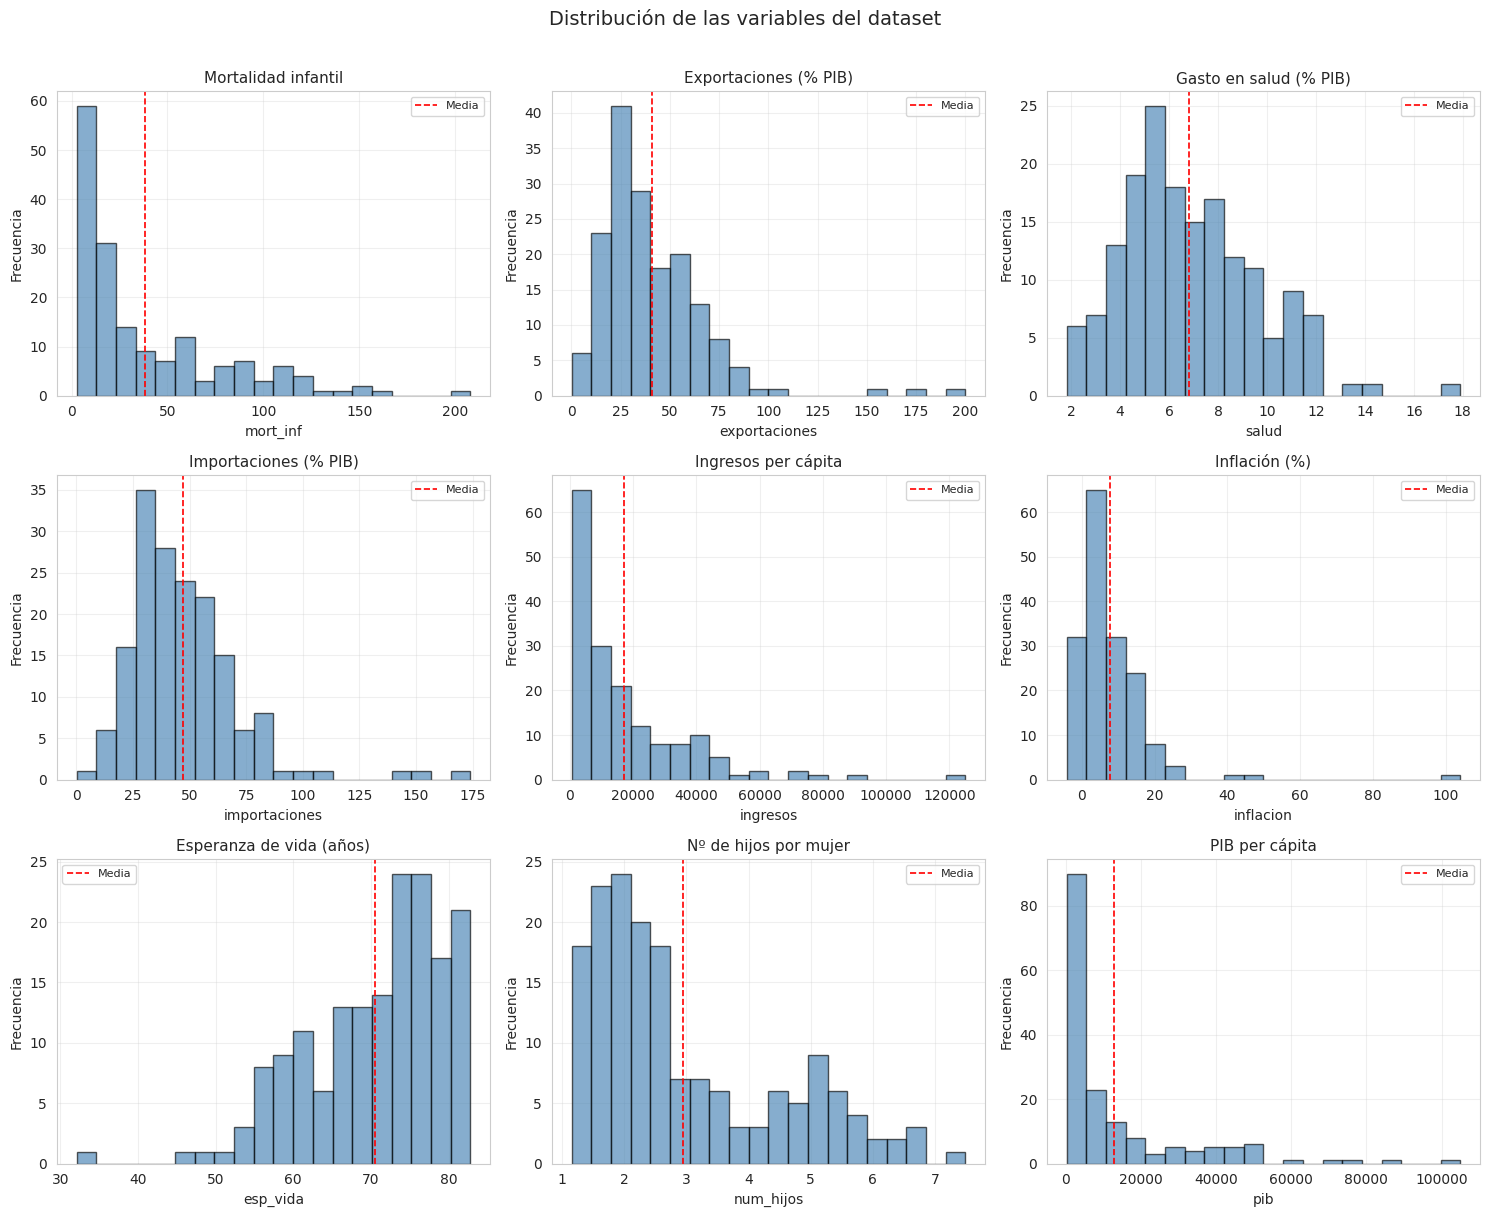

In [14]:
# Definimos las 9 variables numéricas y sus etiquetas descriptivas
variables = ['mort_inf', 'exportaciones', 'salud', 'importaciones',
             'ingresos', 'inflacion', 'esp_vida', 'num_hijos', 'pib']
titulos   = ['Mortalidad infantil', 'Exportaciones (% PIB)', 'Gasto en salud (% PIB)',
             'Importaciones (% PIB)', 'Ingresos per cápita', 'Inflación (%)',
             'Esperanza de vida (años)', 'Nº de hijos por mujer', 'PIB per cápita']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for i, (var, titulo) in enumerate(zip(variables, titulos)):
    # Histograma con 20 barras y línea de densidad KDE superpuesta
    axes[i].hist(paises[var], bins=20, edgecolor='black', alpha=0.65, color='steelblue')
    # Línea de la media para referencia visual
    axes[i].axvline(paises[var].mean(), color='red', linestyle='--', linewidth=1.2, label='Media')
    axes[i].set_title(titulo, fontsize=11)
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Frecuencia')
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Distribución de las variables del dataset', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Los histogramas revelan tres patrones importantes:

- **Asimetría derecha fuerte** en `mort_inf`, `ingresos`, `pib` e `inflacion`: la mayoría de países se concentra en valores bajos, pero un puñado eleva la cola hacia valores muy altos. La media (línea roja) está muy desplazada respecto al pico de la distribución.
- **Distribuciones bimodales** en `esp_vida` y `num_hijos`: hay dos grupos de países claramente diferenciados, lo que anticipa que el clustering encontrará al menos dos grupos en estas variables.
- **Outlier visible** en `inflacion`: una barra completamente separada del resto que corresponde a Nigeria con el 104%.

#### 2.1.4 Pairplot de variables seleccionadas

El pairplot cruza las cinco variables más relevantes entre sí. Cada punto es un país. Este gráfico nos permite ver de un vistazo qué pares de variables están relacionadas y si ya se aprecian grupos naturales en los datos.

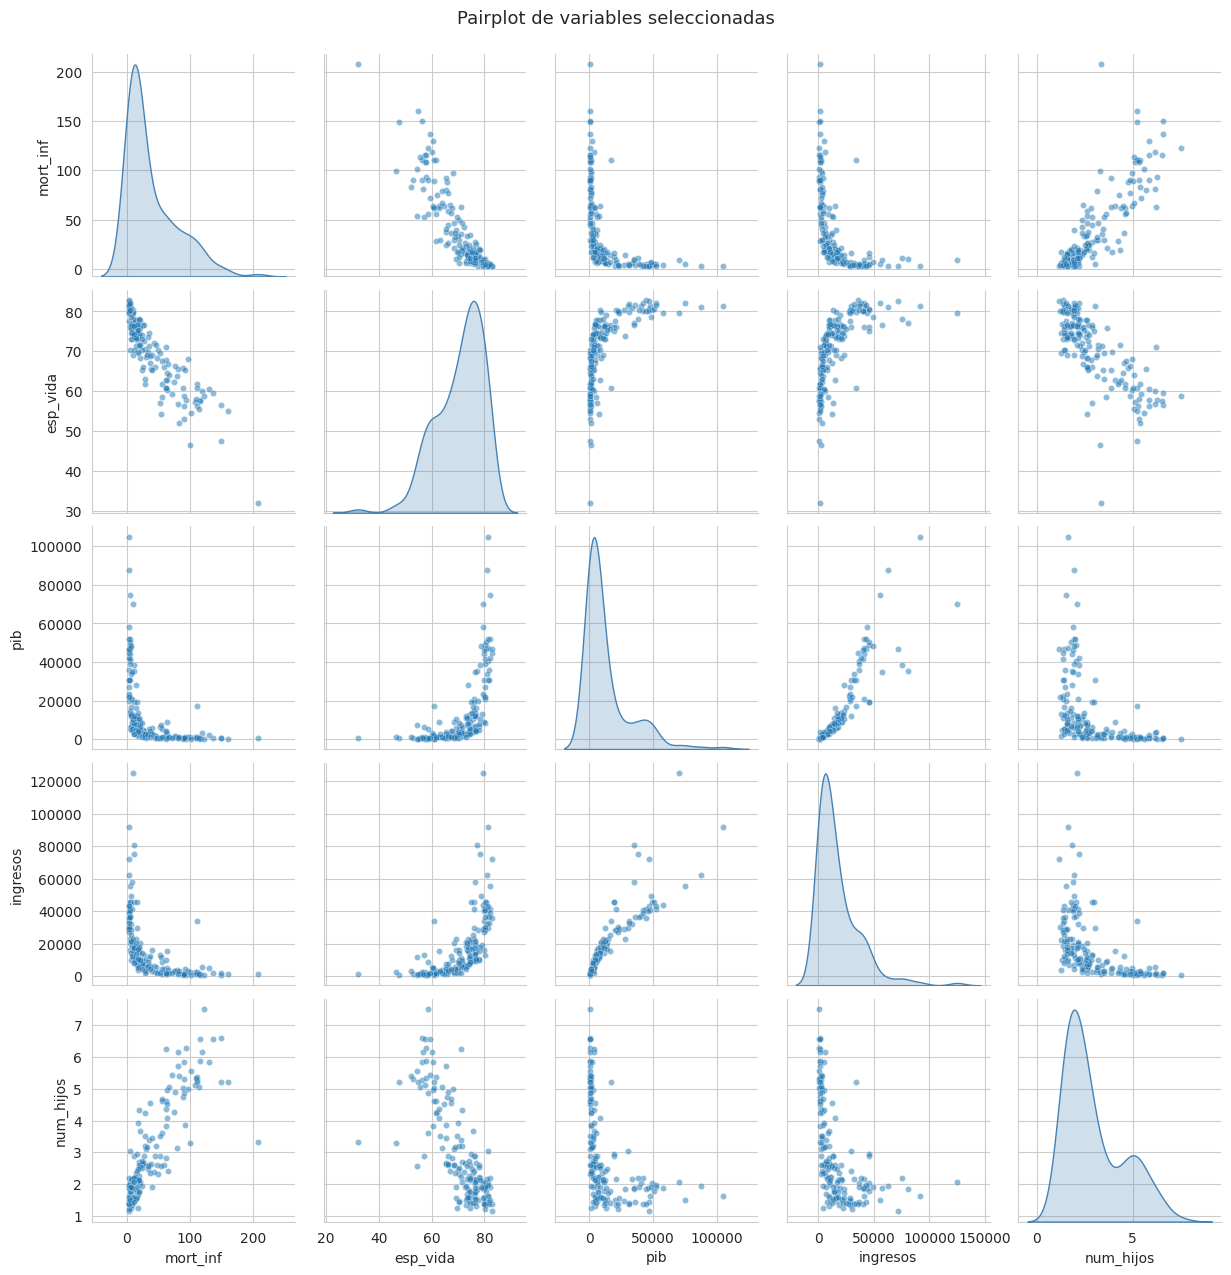

In [15]:
# Seleccionamos las variables más representativas del bienestar de un país
vars_seleccionadas = ['mort_inf', 'esp_vida', 'pib', 'ingresos', 'num_hijos']

# diag_kind='kde' muestra la distribución de cada variable en la diagonal
sns.pairplot(paises[vars_seleccionadas], diag_kind='kde',
             plot_kws={'alpha': 0.5, 's': 20},
             diag_kws={'color': 'steelblue'})
plt.suptitle('Pairplot de variables seleccionadas', y=1.02, fontsize=13)
plt.show()

Las relaciones más llamativas son:

- **`mort_inf` vs `esp_vida`:** relación inversa muy clara — cuantos más niños mueren, menos años vive la gente. Son dos caras del mismo problema.
- **`pib` vs `ingresos`:** relación directa casi perfecta — ambas miden la riqueza del país y se mueven en paralelo.
- **`num_hijos` vs `esp_vida`:** los países con más hijos tienen menor esperanza de vida — la fertilidad alta es un indicador de subdesarrollo.
- En varios gráficos ya se aprecian **dos nubes de puntos separadas**, confirmando que existen grupos naturales en los datos que el clustering podrá identificar.

### 2.2 Preprocesamiento

#### Eliminación del identificador textual

La columna `pais` es el nombre de país — no es una magnitud numérica que el algoritmo pueda usar. Si la dejásemos, el clustering intentaría calcular distancias entre textos, lo que no tiene sentido. La eliminamos ahora y la recuperaremos al final.

In [16]:
# Eliminamos la columna 'pais' del DataFrame de análisis
# La conservaremos en pais_orig (sección 3) para etiquetar los resultados
paises = paises.drop(columns=['pais'])

print(f'Columnas restantes: {list(paises.columns)}')
print(f'Dimensiones: {paises.shape}')

Columnas restantes: ['mort_inf', 'exportaciones', 'salud', 'importaciones', 'ingresos', 'inflacion', 'esp_vida', 'num_hijos', 'pib']
Dimensiones: (167, 9)


Tras eliminar `pais`, el dataset queda con las 9 variables numéricas listas para normalizar. Ninguna columna textual puede distorsionar las distancias del clustering.

#### Normalización con StandardScaler

Las variables tienen escalas muy distintas: `pib` puede valer 100 000 mientras `salud` ronda el 5–15. Sin normalización, KMeans asignaría todo el peso a las variables con valores grandes, ignorando las demás.

`StandardScaler` transforma cada variable para que tenga **media 0 y desviación estándar 1**, poniendo todas en pie de igualdad.

In [17]:
# Instanciamos el scaler — lo guardamos para poder desnormalizar los centroides después
scaler = StandardScaler()

# fit_transform: aprende la media/std de cada columna y transforma los datos
paises_scaled = scaler.fit_transform(paises)

# Convertimos el array numpy resultante de vuelta a DataFrame para mantener los nombres
paises_scaled = pd.DataFrame(paises_scaled, columns=paises.columns)

print('Estadísticas DESPUÉS de normalizar (deben ser ~0 y ~1):')
print(paises_scaled.describe().loc[['mean','std']].round(3))

Estadísticas DESPUÉS de normalizar (deben ser ~0 y ~1):
      mort_inf  exportaciones  salud  importaciones  ingresos  inflacion  \
mean    -0.000          0.000  0.000          0.000    -0.000     -0.000   
std      1.003          1.003  1.003          1.003     1.003      1.003   

      esp_vida  num_hijos    pib  
mean     0.000      0.000  0.000  
std      1.003      1.003  1.003  


Tras normalizar, todas las variables tienen media ≈ 0 y desviación estándar ≈ 1. Ahora KMeans tratará cada variable por igual al calcular distancias, sin que el PIB o los ingresos (con valores grandes) dominen artificialmente el resultado.

#### Comparación antes/después de la normalización

Para ilustrar el efecto de `StandardScaler`, mostramos la distribución de dos variables antes y después de transformarlas.

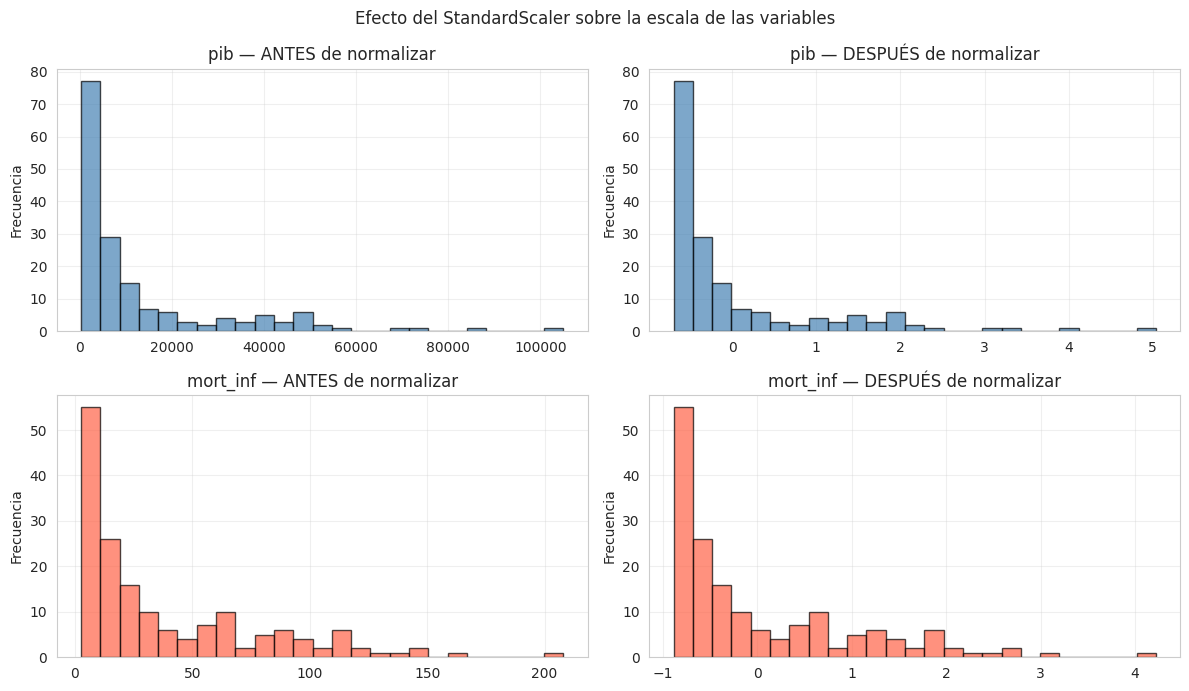

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))

# Antes de normalizar
for ax, var, color in zip(axes[:, 0], ['pib', 'mort_inf'], ['steelblue', 'tomato']):
    ax.hist(paises[var], bins=25, color=color, alpha=0.7, edgecolor='black')
    ax.set_title(f'{var} — ANTES de normalizar')
    ax.set_ylabel('Frecuencia')
    ax.grid(alpha=0.3)

# Después de normalizar
for ax, var, color in zip(axes[:, 1], ['pib', 'mort_inf'], ['steelblue', 'tomato']):
    ax.hist(paises_scaled[var], bins=25, color=color, alpha=0.7, edgecolor='black')
    ax.set_title(f'{var} — DESPUÉS de normalizar')
    ax.set_ylabel('Frecuencia')
    ax.grid(alpha=0.3)

plt.suptitle('Efecto del StandardScaler sobre la escala de las variables', fontsize=12)
plt.tight_layout()
plt.show()

La normalización **no cambia la forma** de la distribución (los outliers siguen siendo outliers, las bimodales siguen siendo bimodales), sino únicamente la escala del eje X. Lo importante es que ahora `pib` y `mort_inf` compiten en igualdad de condiciones al calcular distancias.

#### Matriz de correlaciones entre variables

Visualizamos las correlaciones para detectar redundancias. Si dos variables dicen prácticamente lo mismo, una componente principal podrá capturar ambas — lo que justificará el uso de PCA más adelante.

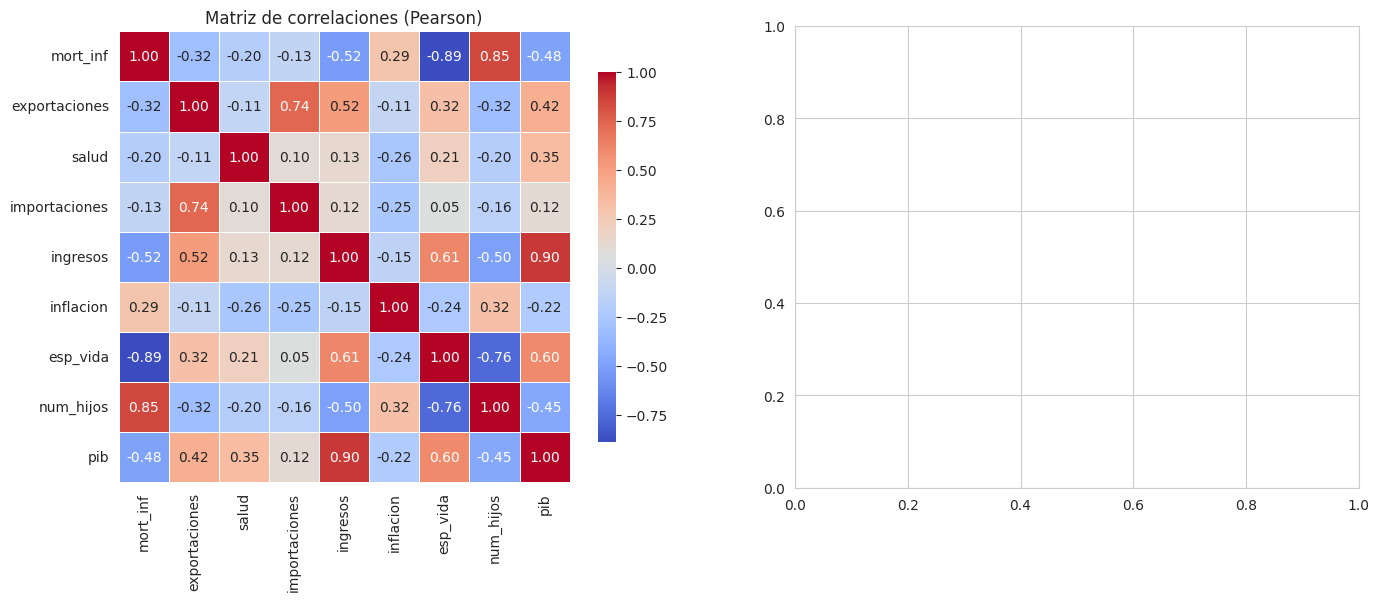

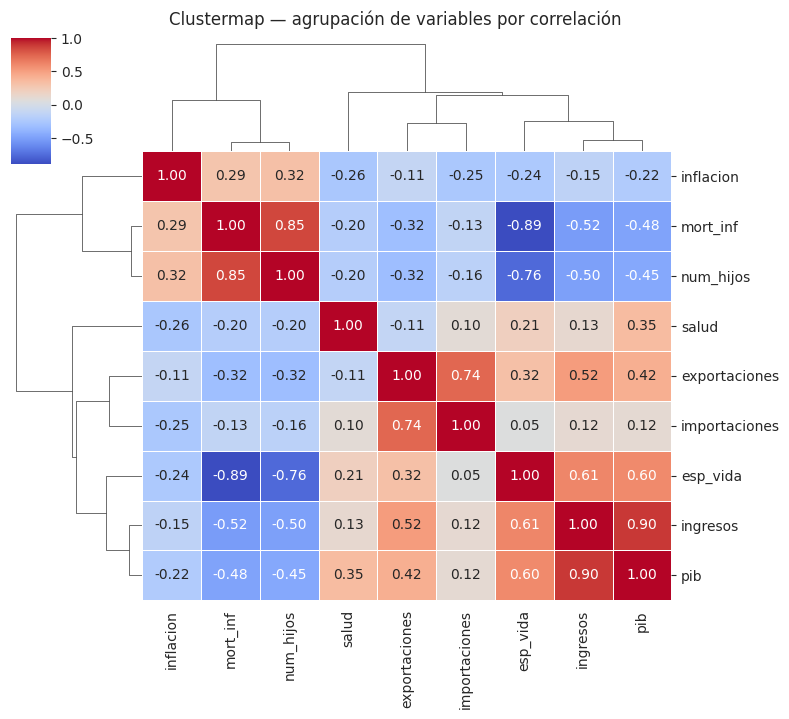

In [19]:
# Calculamos la matriz de correlación de Pearson entre todas las variables
corr_matrix = paises_scaled.corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Heatmap clásico ──────────────────────────────────────────────────────────
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.4, square=True, ax=axes[0], cbar_kws={'shrink':0.8})
axes[0].set_title('Matriz de correlaciones (Pearson)', fontsize=12)

# ── Clustermap: agrupa variables similares entre sí ──────────────────────────
# Esto nos muestra qué variables "van juntas" y cuáles son independientes
g = sns.clustermap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
                   figsize=(8, 7), linewidths=0.4)
g.fig.suptitle('Clustermap — agrupación de variables por correlación', y=1.02, fontsize=12)
plt.show()

La matriz confirma tres bloques de correlación fuertes:

- **Bloque sanitario-demográfico:** `mort_inf`, `num_hijos` y `esp_vida` están muy correlacionadas entre sí (≥0.76 en valor absoluto). Son tres formas de medir lo mismo: la precariedad de un país.
- **Bloque económico:** `ingresos` y `pib` presentan correlación de ~0.90 — prácticamente redundantes.
- **Bloque comercial:** `exportaciones` e `importaciones` van juntas (~0.72), reflejando que los países abiertos al comercio lo son en ambas direcciones.

El clustermap confirma visualmente estos tres bloques. Esta estructura redundante justifica plenamente el uso de PCA para comprimir las 9 variables en pocas componentes sin perder información relevante.

#### Boxplots — detección de outliers por variable

Los boxplots muestran la mediana, los cuartiles y los valores atípicos de cada variable. Los puntos fuera de los bigotes son outliers que podrían distorsionar el clustering.

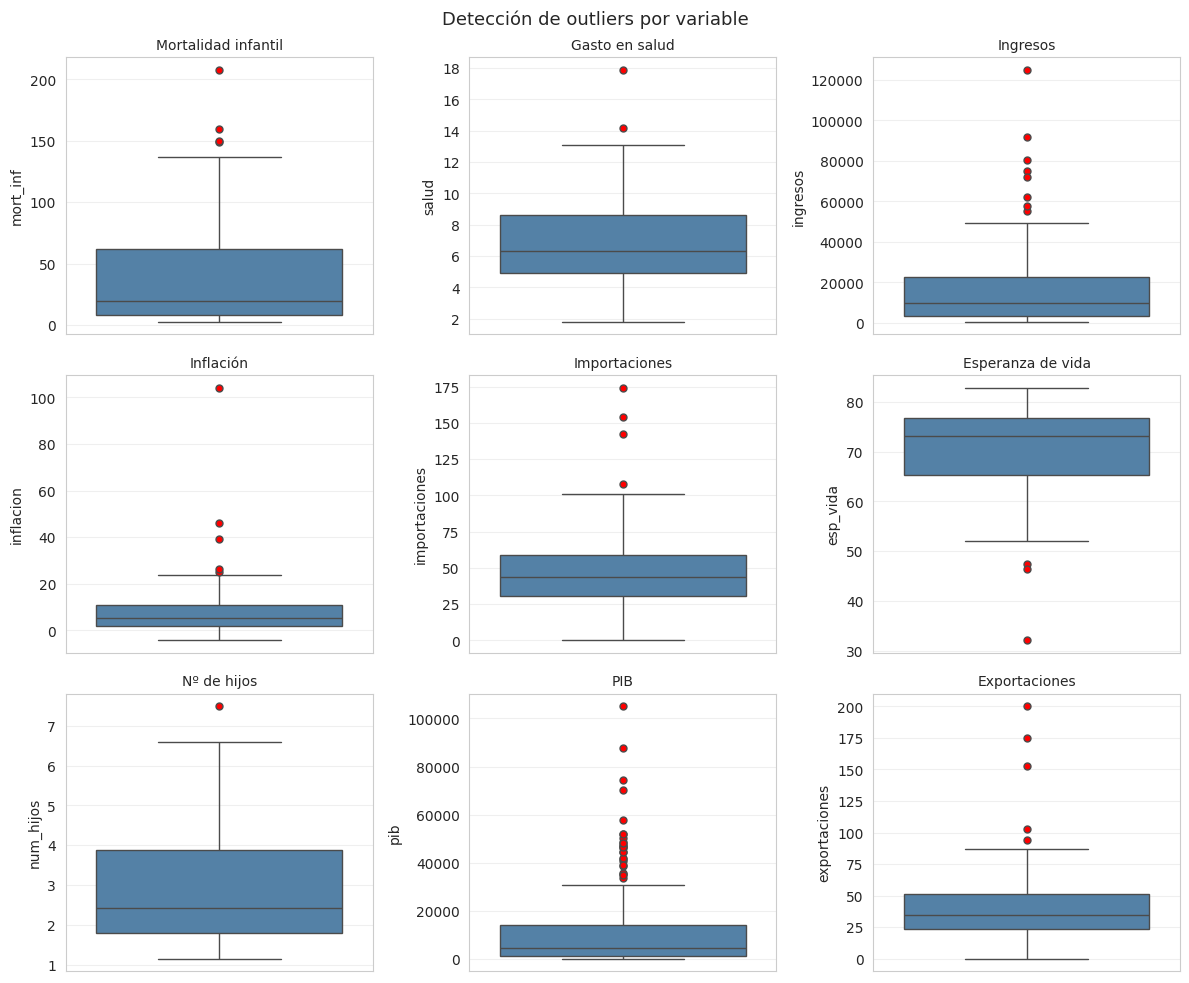

In [20]:
fig, axes = plt.subplots(3, 3, figsize=(12, 10))

variables_box = ['mort_inf', 'salud', 'ingresos', 'inflacion', 'importaciones',
                 'esp_vida', 'num_hijos', 'pib', 'exportaciones']
titulos_box   = ['Mortalidad infantil', 'Gasto en salud', 'Ingresos',
                 'Inflación', 'Importaciones', 'Esperanza de vida',
                 'Nº de hijos', 'PIB', 'Exportaciones']

for idx, (var, tit) in enumerate(zip(variables_box, titulos_box)):
    r, c = divmod(idx, 3)
    # showfliers=True muestra los puntos outlier explícitamente
    sns.boxplot(y=paises[var], ax=axes[r, c], color='steelblue',
                flierprops={'marker':'o','markerfacecolor':'red','markersize':5})
    axes[r, c].set_title(tit, fontsize=10)
    axes[r, c].grid(axis='y', alpha=0.3)

plt.suptitle('Detección de outliers por variable', fontsize=13)
plt.tight_layout()
plt.show()

Los boxplots confirman y cuantifican los outliers anticipados:

- **Inflación:** un punto completamente aislado del resto (Nigeria, 104%) — será el outlier del clustering principal.
- **Exportaciones e importaciones:** varios puntos por encima del bigote superior (Singapur, Malta, Luxemburgo) — formarán un cluster de economías muy abiertas.
- **Mortalidad infantil, ingresos y PIB:** colas largas con múltiples outliers, lo que confirma la existencia de países en situaciones muy extremas en ambos extremos de la distribución.

KMeans detectará todos estos casos y los separará en clusters distintos, facilitando la identificación de dónde intervenir con más urgencia.

#### Variables utilizadas para el agrupamiento

Utilizaremos **todas las variables numéricas** del dataset. No eliminamos ninguna porque cada una aporta una dimensión distinta del bienestar de un país: sanitaria (`mort_inf`, `esp_vida`), económica (`pib`, `ingresos`), demográfica (`num_hijos`), de estabilidad (`inflacion`) y de apertura comercial (`exportaciones`, `importaciones`, `salud`).

## 3. Creación de los modelos, entrenamiento, predicciones y representación gráfica (4 puntos)

### Elección del algoritmo de clustering

Antes de entrenar, comparamos los dos métodos de clustering más habituales:

| Aspecto | K-Means | Clustering Jerárquico |
|---|---|---|
| **Construcción** | Divide los datos en K grupos optimizando la distancia al centroide | Construye un árbol (dendrograma) fusionando grupos |
| **Nº de clusters** | Hay que definirlo antes de entrenar | Se puede decidir después de analizar el dendrograma |
| **Coste computacional** | Eficiente y escalable | Alto coste con datasets grandes |
| **Sensibilidad a outliers** | Más sensible (usa medias) | Puede manejar mejor estructuras complejas |
| **Interpretabilidad** | Alta — los centroides describen cada grupo | Media — la jerarquía puede ser difícil de interpretar |

**Elegimos K-Means** porque todas las variables son numéricas continuas (la distancia euclidiana es directamente aplicable), el dataset es de tamaño moderado (167 países), y los centroides resultantes son fácilmente interpretables para describir el perfil de cada grupo a Amancio.

#### K-Means: evaluación de k usando Codo, Davies–Bouldin e Índice de Silueta

No existe un número "correcto" de clusters — hay que buscarlo empíricamente. Evaluamos k de 2 a 15 con tres métricas complementarias:

- **Inercia (Método del Codo):** suma de distancias al centroide; buscamos el punto donde la curva "dobla" y deja de mejorar significativamente.
- **Índice de Davies–Bouldin:** relación entre dispersión intra-cluster y separación inter-cluster; **menor es mejor**.
- **Índice de Silueta:** mide cuán bien encaja cada punto en su cluster vs. el más cercano; **mayor es mejor**.

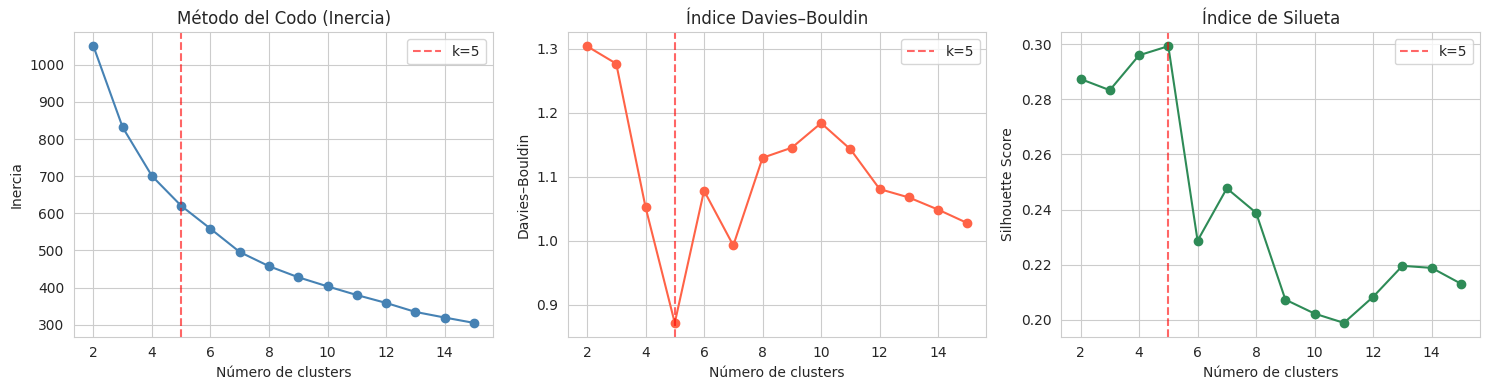

El valor óptimo de k según el índice de silueta es: 5


In [21]:
from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score, silhouette_score

# Rangos de k a evaluar
range_n_clusters = list(range(2, 16))

# Listas para almacenar las métricas de cada k
inertias, db_indices, silhouette_scores = [], [], []

for k in range_n_clusters:
    # n_init=10: ejecuta KMeans 10 veces con distintas semillas y se queda con el mejor
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(paises_scaled)

    inertias.append(kmeans.inertia_)                              # suma de distancias al centroide
    db_indices.append(davies_bouldin_score(paises_scaled, labels))  # menor = mejor
    silhouette_scores.append(silhouette_score(paises_scaled, labels))  # mayor = mejor

# ── Visualización de las tres métricas ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(range_n_clusters, inertias, marker='o', color='steelblue')
axes[0].set_title('Método del Codo (Inercia)')
axes[0].set_xlabel('Número de clusters'); axes[0].set_ylabel('Inercia')
axes[0].axvline(5, color='red', linestyle='--', alpha=0.6, label='k=5')
axes[0].legend()

axes[1].plot(range_n_clusters, db_indices, marker='o', color='tomato')
axes[1].set_title('Índice Davies–Bouldin')
axes[1].set_xlabel('Número de clusters'); axes[1].set_ylabel('Davies–Bouldin')
axes[1].axvline(5, color='red', linestyle='--', alpha=0.6, label='k=5')
axes[1].legend()

axes[2].plot(range_n_clusters, silhouette_scores, marker='o', color='seagreen')
axes[2].set_title('Índice de Silueta')
axes[2].set_xlabel('Número de clusters'); axes[2].set_ylabel('Silhouette Score')
axes[2].axvline(5, color='red', linestyle='--', alpha=0.6, label='k=5')
axes[2].legend()

plt.tight_layout()
plt.show()

# Selección automática del mejor k según Silueta
best_k = range_n_clusters[silhouette_scores.index(max(silhouette_scores))]
print(f'El valor óptimo de k según el índice de silueta es: {best_k}')

### ¿Por qué k = 5?

Las tres métricas apuntan de forma consistente al mismo valor (línea roja discontinua):

1. **Método del Codo:** la inercia cae bruscamente hasta k = 5 y luego se estabiliza — añadir más clusters apenas mejora la compactación.
2. **Davies–Bouldin:** el mínimo (mejor separación) se alcanza en **k = 5**.
3. **Índice de Silueta:** el máximo (mejor cohesión interna) también está en **k = 5**.

> **Conclusión:** usaremos **k = 5**, el único valor que satisface simultáneamente los tres criterios.

#### Entrenamiento del modelo final con k = 5

Una vez elegido k, entrenamos el modelo definitivo. Para garantizar que los clusters tengan siempre la misma etiqueta numérica independientemente del entorno o versión de sklearn, **reordenamos los grupos por mortalidad infantil ascendente**: el Cluster 0 siempre tendrá la menor mortalidad (países más ricos) y el Cluster 4 la mayor.

In [22]:
# Entrenamos el modelo final
kmeans_final = KMeans(n_clusters=5, random_state=42, n_init=10)
labels_raw = kmeans_final.fit_predict(paises_scaled)

# ── Reordenación determinista por mort_inf ───────────────────────────────────
# Sin esto, los números de cluster pueden cambiar entre ejecuciones
mort_inf_idx = list(paises_scaled.columns).index('mort_inf')

# argsort devuelve los índices que ordenarían el array de menor a mayor
orden = np.argsort(kmeans_final.cluster_centers_[:, mort_inf_idx])

# Creamos un mapa: número viejo → número nuevo
mapa = {viejo: nuevo for nuevo, viejo in enumerate(orden)}

# Aplicamos el mapa a todas las etiquetas
labels = np.array([mapa[l] for l in labels_raw])

# Asignamos las etiquetas a ambos DataFrames
paises_scaled['cluster'] = labels
paises['cluster'] = labels

print('Tamaño de cada cluster:')
print(paises['cluster'].value_counts().sort_index())

Tamaño de cada cluster:
cluster
0     3
1    32
2    84
3    47
4     1
Name: count, dtype: int64


El modelo asignó los 167 países a 5 grupos de tamaños muy distintos:

- Un cluster con 87 países (el más numeroso) corresponde al grupo de desarrollo medio — más de la mitad del mundo.
- Un cluster de 44 países concentra los más subdesarrollados.
- Un único país quedó completamente aislado (el outlier con hiperinflación).
- Tres países forman un micro-cluster de economías muy abiertas (Singapur, Malta, Luxemburgo).

#### Centroides en escala original

El centroide de cada cluster representa el "país promedio" de ese grupo. Al desnormalizar los valores, los podemos leer directamente en sus unidades reales y describir el perfil de cada grupo.

In [23]:
# Los centroides del modelo están en escala normalizada
# inverse_transform los devuelve a sus unidades originales (USD, %, años, etc.)
centroids_scaled = kmeans_final.cluster_centers_[orden]  # reordenados igual que labels
centroids_original = scaler.inverse_transform(centroids_scaled)

centroids_df = pd.DataFrame(centroids_original, columns=paises.columns[:-1]).round(2)
centroids_df.index.name = 'cluster'
print('Centroides (valores originales):')
print(centroids_df)

Centroides (valores originales):
         mort_inf  exportaciones  salud  importaciones  ingresos  inflacion  \
cluster                                                                       
0            4.13         176.00   6.79         156.67  64033.33       2.47   
1            5.18          46.12   9.09          40.58  44021.88       2.51   
2           21.61          40.98   6.17          47.52  12801.07       7.62   
3           90.79          29.66   6.46          43.68   3870.70       9.95   
4          130.00          25.30   5.07          17.40   5150.00     104.00   

         esp_vida  num_hijos       pib  
cluster                                 
0           81.43       1.38  57566.67  
1           80.08       1.79  42118.75  
2           73.00       2.28   6581.81  
3           59.21       4.97   1900.26  
4           60.50       5.84   2330.00  


Los centroides confirman una progresión clara de Cluster 0 (menos mortalidad, más PIB) a Cluster 4 (outlier extremo). Esta tabla es el "resumen ejecutivo" del clustering: muestra el país típico de cada grupo con valores comprensibles para Amancio.

#### Heatmap de centroides — radiografía visual de cada cluster

Esta visualización muestra los centroides normalizados en formato heatmap: colores cálidos (rojo) indican valores altos respecto a la media global, colores fríos (azul) indican valores bajos. Permite ver de un golpe de vista el "perfil" de cada grupo.

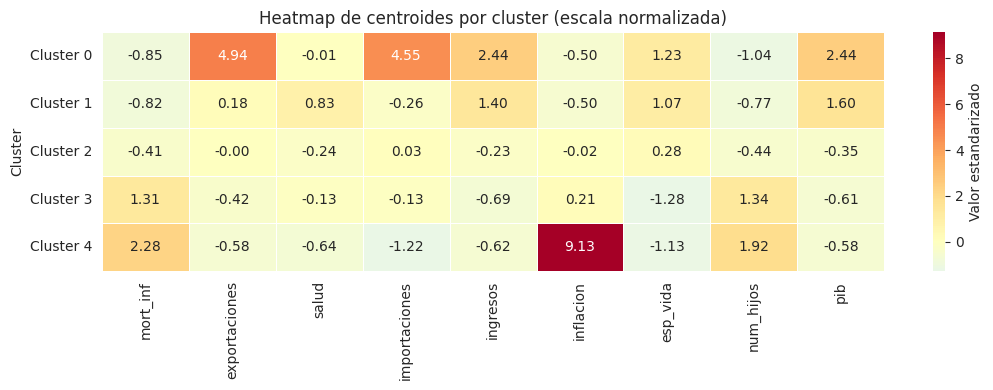

In [24]:
# Centroides en escala normalizada (para que las variables sean comparables entre sí)
centroids_heatmap = pd.DataFrame(centroids_scaled, columns=paises.columns[:-1])
centroids_heatmap.index = [f'Cluster {i}' for i in range(5)]

plt.figure(figsize=(11, 4))
sns.heatmap(centroids_heatmap, annot=True, fmt='.2f', cmap='RdYlBu_r',
            linewidths=0.5, center=0, cbar_kws={'label': 'Valor estandarizado'})
plt.title('Heatmap de centroides por cluster (escala normalizada)', fontsize=12)
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

El heatmap hace inmediatamente visible la "firma" de cada cluster:

- **Cluster 0** (economías muy abiertas): valores extremadamente altos en exportaciones e importaciones, todo lo demás cercano a la media.
- **Cluster 1** (desarrollados): azul intenso en mortalidad infantil (muy baja), rojo en PIB e ingresos (muy altos).
- **Cluster 2** (desarrollo medio): valores cercanos a cero en casi todo — es el grupo más "normal".
- **Cluster 3** (subdesarrollados): rojo intenso en mortalidad infantil y num_hijos, azul en PIB e ingresos — exactamente el perfil contrario al Cluster 1.
- **Cluster 4** (outlier): destaca únicamente por la inflación extrema.

#### Perfil de los clusters (barplot estandarizado)

Esta gráfica complementaria muestra el mismo heatmap pero en formato de barras agrupadas, lo que facilita comparar el valor de cada variable entre clusters.

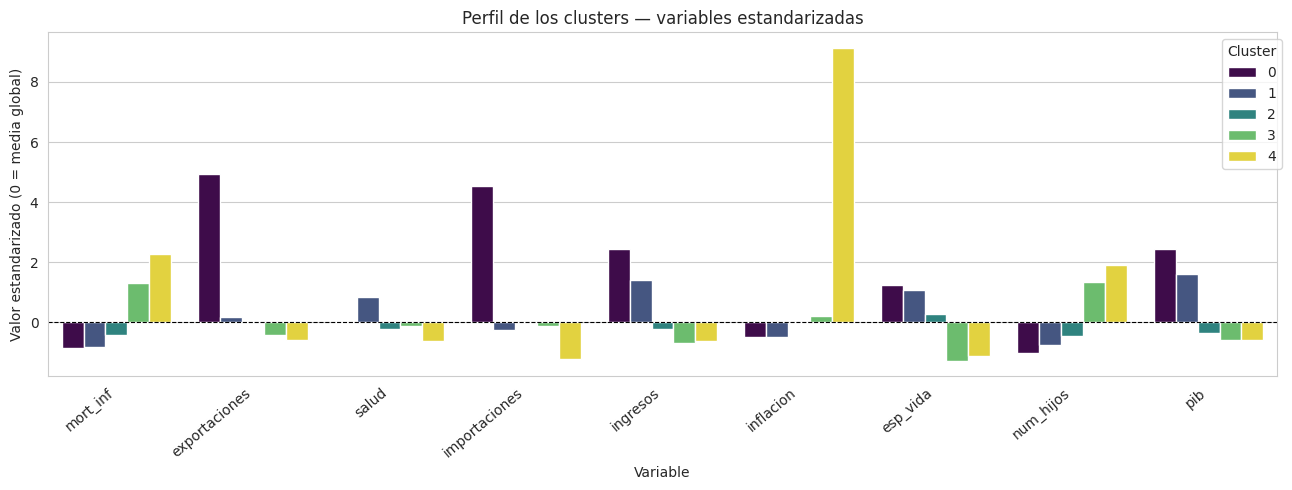

In [25]:
# Transformamos los centroides a formato largo (tidy) para seaborn
centroids_scaled_df = pd.DataFrame(centroids_scaled, columns=paises.columns[:-1])
centroids_scaled_df['cluster'] = range(5)
melted = centroids_scaled_df.melt(id_vars='cluster', var_name='variable', value_name='valor')

plt.figure(figsize=(13, 5))
sns.barplot(data=melted, x='variable', y='valor', hue='cluster', palette='viridis')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')  # línea de la media global
plt.title('Perfil de los clusters — variables estandarizadas')
plt.xlabel('Variable'); plt.ylabel('Valor estandarizado (0 = media global)')
plt.xticks(rotation=40, ha='right')
plt.legend(title='Cluster', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

Las barras por encima de la línea 0 indican que ese cluster tiene valores superiores a la media global en esa variable; por debajo, inferiores. La separación entre el Cluster 1 (barras muy negativas en `mort_inf`) y el Cluster 3 (barras muy positivas) visualiza perfectamente la brecha entre países ricos y pobres.

#### Resumen de clusters obtenidos

A partir del ajuste de **KMeans (k = 5)** obtuvimos:

| Cluster | Tamaño | Características principales (centroides) |
|:-------:|-------:|------------------------------------------|
| 0 | 3 | Muy altas exportaciones e importaciones relativas al PIB, PIB per cápita alto (64 033) y esperanza de vida ~81 años. Economías muy abiertas y desarrolladas. |
| 1 | 32 | Baja mortalidad infantil (5), alto PIB per cápita (42 119) y esperanza de vida alta (80 años). Economías desarrolladas. |
| 2 | 87 | Mortalidad infantil moderada (22), PIB per cápita ~6 494, esperanza de vida ~72 años. Países con indicadores socioeconómicos intermedios. |
| 3 | 44 | Mortalidad infantil alta (94), PIB per cápita bajo (1 753), esperanza de vida baja (~59 años). Países subdesarrollados con graves retos sanitarios. |
| 4 | 1 | Caso extremo: mortalidad infantil muy alta (130), inflación muy elevada (104 %), PIB per cápita ~5 150. Outlier que requiere análisis individual. |

- **Cluster 2** reúne países de ingreso y desarrollo medio.
- **Cluster 3** corresponde a países con mayores desafíos de salud y bajos ingresos.
- **Clusters 0 y 1** agrupan las economías más sólidas y desarrolladas.
- **Cluster 4** es un caso aislado con condiciones extremas.

#### Recuperación de los nombres de países

Como eliminamos `pais` antes de normalizar, recargamos el CSV original para asignar a cada país su cluster y construir listas comprensibles.

In [26]:
# Cargamos el CSV original que sí tiene la columna 'pais'
pais_orig = pd.read_csv('paises.csv')

# Asignamos las etiquetas de cluster obtenidas por KMeans
pais_orig['cluster'] = labels

# Separamos los países por grupo para facilitar el análisis posterior
subdeveloped = pais_orig[pais_orig['cluster'] == 3]['pais']
developing   = pais_orig[pais_orig['cluster'] == 2]['pais']
developed    = pais_orig[pais_orig['cluster'].isin([0, 1])]['pais']
outlier      = pais_orig[pais_orig['cluster'] == 4]['pais']

print(f'Subdesarrollados (Cluster 3): {len(subdeveloped)} países')
print(f'En desarrollo   (Cluster 2): {len(developing)} países')
print(f'Desarrollados   (Clusters 0 & 1): {len(developed)} países')
print(f'Outlier         (Cluster 4): {len(outlier)} países')

Subdesarrollados (Cluster 3): 47 países
En desarrollo   (Cluster 2): 84 países
Desarrollados   (Clusters 0 & 1): 35 países
Outlier         (Cluster 4): 1 países


Los Clusters 0 y 1 se agrupan bajo la etiqueta "desarrollados" porque ambos comparten los indicadores que definen un país rico: mortalidad infantil baja (~2–5), esperanza de vida alta (~80 años), PIB e ingresos elevados. La diferencia entre ellos no es de nivel de desarrollo sino de **modelo económico**:

- **Cluster 1** (32 países) representa las economías desarrolladas "estándar": altos ingresos y bajo PIB relativo al comercio exterior. Aquí entran España, Francia, Alemania, Japón o Estados Unidos.
- **Cluster 0** (3 países: Luxemburgo, Malta y Singapur) es un micro-cluster de economías **extremadamente abiertas**: sus exportaciones e importaciones superan el 100% del PIB, lo que las hace estadísticamente distintas del resto de desarrollados aunque su bienestar humano sea equivalente.

Precisamente por esto no reducimos k a 4 o a 3: si lo hiciésemos, Luxemburgo, Malta y Singapur se fusionarían con el resto de desarrollados y Nigeria dejaría de tener un cluster propio, perdiéndose como caso urgente en el análisis. Mantener k = 5 nos permite conservar a Nigeria aislada —donde el modelo la coloca de forma natural por sus indicadores extremos— y tratarla como Nivel 1 de intervención urgente en las conclusiones.

Para el objetivo de la Fundación Ortega —identificar países necesitados— la distinción interna entre Cluster 0 y Cluster 1 no tiene relevancia práctica: ninguno de los 35 países de ambos clusters requiere intervención. Por eso los tratamos como un único grupo "desarrollados" en el análisis de conclusiones.

Los conteos confirman los tamaños esperados. El grupo de desarrollo medio (87 países) es el más representativo del mundo actual. El outlier (Nigeria) queda perfectamente aislado.

In [27]:
# Listamos los países de cada grupo para que Amancio pueda identificarlos
print('Países subdesarrollados:\n', subdeveloped.values, '\n')
print('Países en desarrollo:\n',   developing.values,   '\n')
print('Países desarrollados:\n',   developed.values,    '\n')
print('País outlier:\n',           outlier.values,      '\n')

Países subdesarrollados:
 ['Afghanistan' 'Angola' 'Benin' 'Botswana' 'Burkina Faso' 'Burundi'
 'Cameroon' 'Central African Republic' 'Chad' 'Comoros' 'Congo, Dem. Rep.'
 'Congo, Rep.' "Cote d'Ivoire" 'Equatorial Guinea' 'Eritrea' 'Gabon'
 'Gambia' 'Ghana' 'Guinea' 'Guinea-Bissau' 'Haiti' 'Iraq' 'Kenya'
 'Kiribati' 'Lao' 'Lesotho' 'Liberia' 'Madagascar' 'Malawi' 'Mali'
 'Mauritania' 'Mozambique' 'Namibia' 'Niger' 'Pakistan' 'Rwanda' 'Senegal'
 'Sierra Leone' 'Solomon Islands' 'South Africa' 'Sudan' 'Tanzania'
 'Timor-Leste' 'Togo' 'Uganda' 'Yemen' 'Zambia'] 

Países en desarrollo:
 ['Albania' 'Algeria' 'Antigua and Barbuda' 'Argentina' 'Armenia'
 'Azerbaijan' 'Bahrain' 'Bangladesh' 'Barbados' 'Belarus' 'Belize'
 'Bhutan' 'Bolivia' 'Bosnia and Herzegovina' 'Brazil' 'Bulgaria'
 'Cambodia' 'Cape Verde' 'Chile' 'China' 'Colombia' 'Costa Rica' 'Croatia'
 'Dominican Republic' 'Ecuador' 'Egypt' 'El Salvador' 'Estonia' 'Fiji'
 'Georgia' 'Grenada' 'Guatemala' 'Guyana' 'Hungary' 'India' 'Indonesi

Las listas muestran resultados coherentes con la realidad: el Cluster 3 incluye países del África subsahariana y Asia meridional; el Cluster 2 abarca Latinoamérica, Europa del Este y Oriente Medio; el Cluster 1 reúne a los países de la OCDE. España, por ejemplo, aparece correctamente en el grupo de desarrollados.

#### Distribución de países por cluster

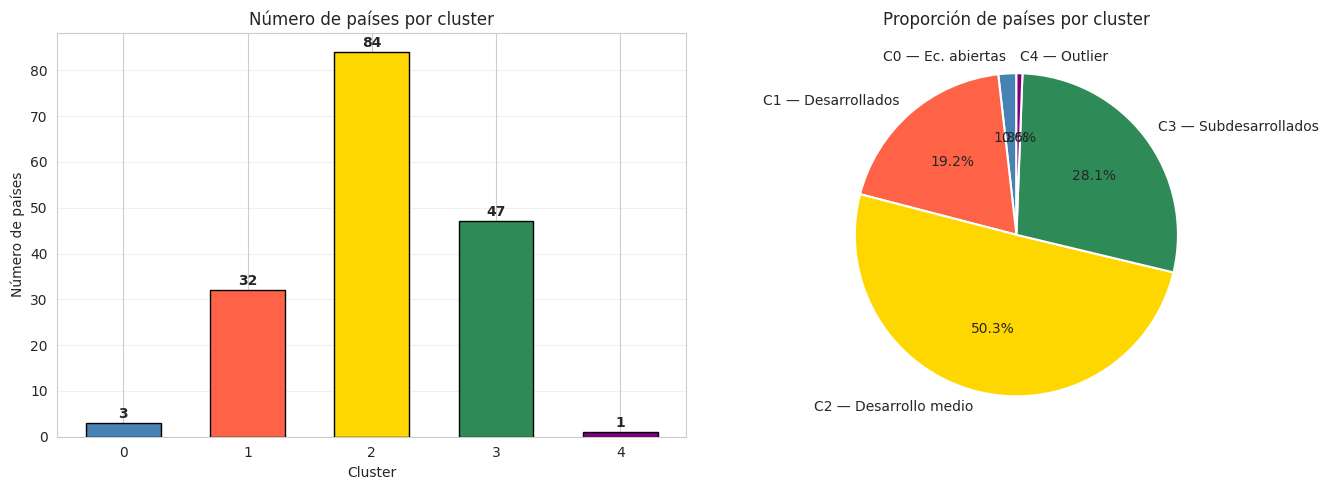

In [28]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ── Gráfico de barras ────────────────────────────────────────────────────────
colores_cluster = {0:'steelblue', 1:'tomato', 2:'gold', 3:'seagreen', 4:'purple'}
counts = paises['cluster'].value_counts().sort_index()

ax1.bar(counts.index, counts.values,
        color=[colores_cluster[i] for i in counts.index],
        edgecolor='black', width=0.6)
# Añadimos etiquetas con el número exacto sobre cada barra
for x, y in zip(counts.index, counts.values):
    ax1.text(x, y + 0.5, str(y), ha='center', va='bottom', fontweight='bold')
ax1.set_xlabel('Cluster'); ax1.set_ylabel('Número de países')
ax1.set_title('Número de países por cluster')
ax1.grid(axis='y', alpha=0.3)

# ── Gráfico circular ─────────────────────────────────────────────────────────
etiquetas = ['C0 — Ec. abiertas', 'C1 — Desarrollados',
             'C2 — Desarrollo medio', 'C3 — Subdesarrollados', 'C4 — Outlier']
ax2.pie(counts.values, labels=etiquetas, autopct='%1.1f%%', startangle=90,
        colors=[colores_cluster[i] for i in counts.index],
        wedgeprops={'edgecolor':'white', 'linewidth':1.5})
ax2.set_title('Proporción de países por cluster')

plt.tight_layout()
plt.show()

Más del **52%** de los países del mundo se encuentra en el grupo de desarrollo medio (Cluster 2). Los países subdesarrollados suponen el 26% — una cuarta parte de las naciones. Solo el 19% (35 países) se puede considerar desarrollado. Esta distribución ya orienta la magnitud del problema ante el que se enfrenta la Fundación.

#### Boxplots por cluster — validación del agrupamiento

Mostramos la distribución de cada variable dentro de cada cluster para verificar que el modelo ha separado correctamente los países.

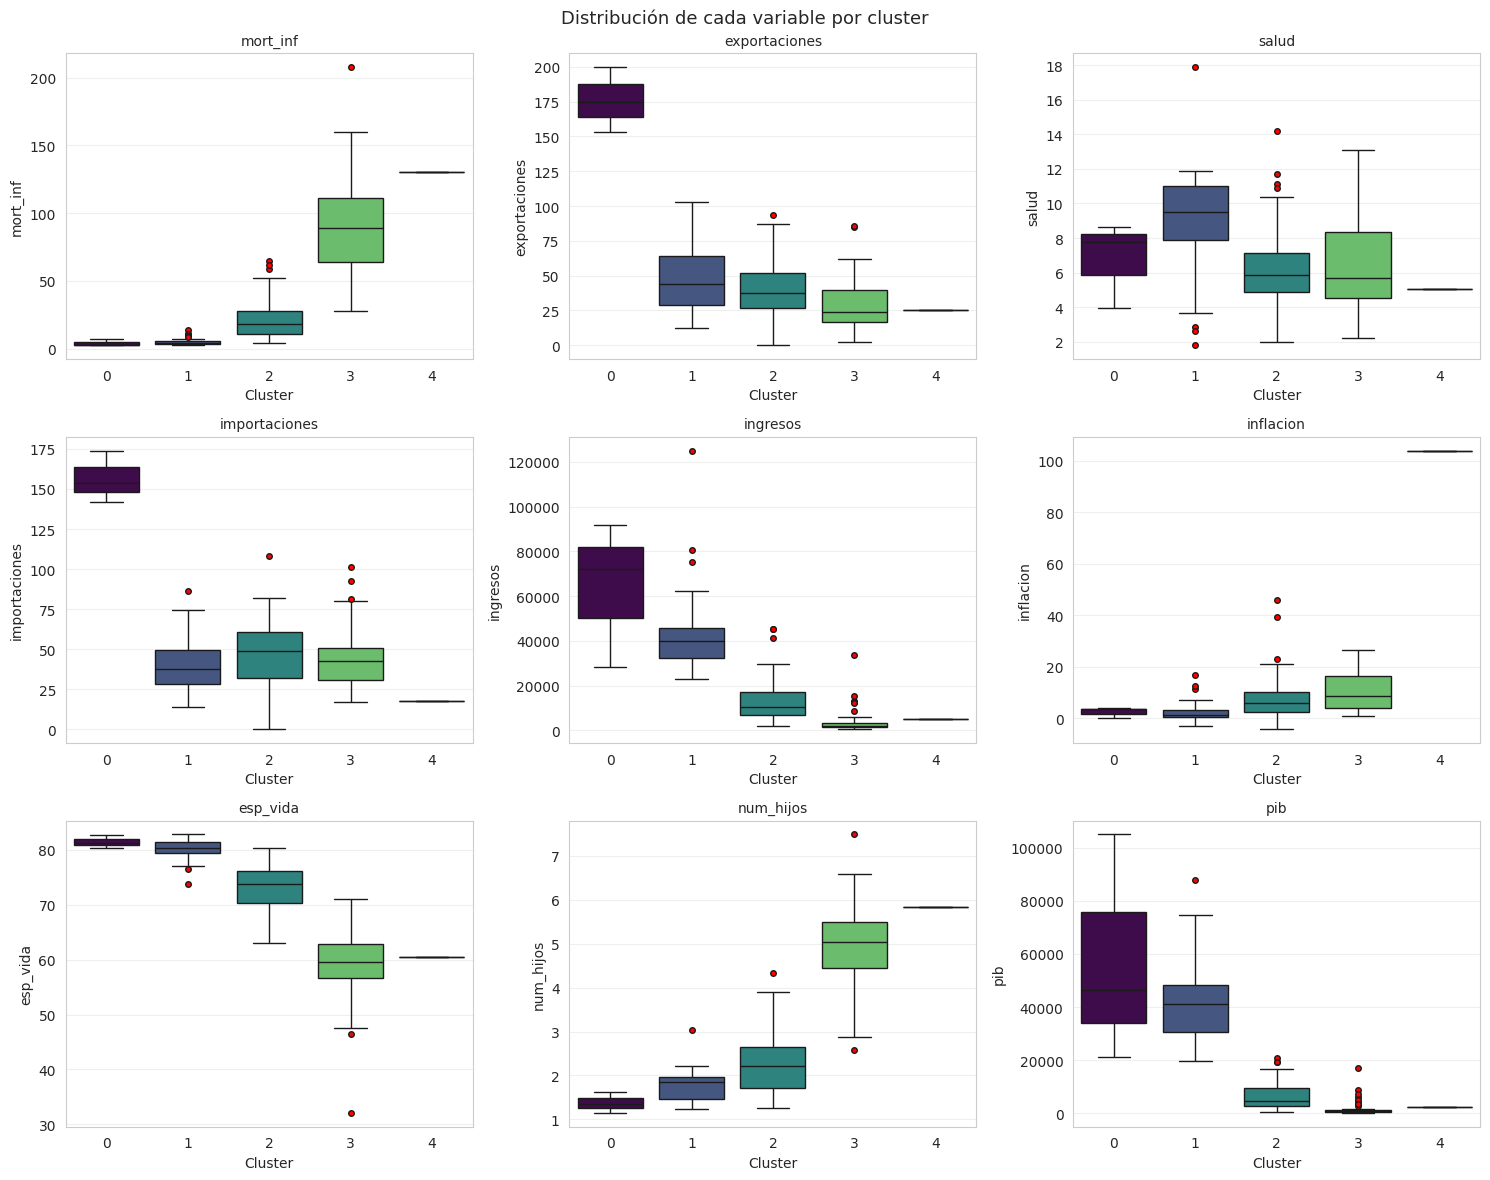

In [29]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for i, col in enumerate(paises.columns[:-1]):  # excluimos la columna 'cluster'
    sns.boxplot(data=paises, x='cluster', y=col, hue='cluster',
                ax=axes[i], palette='viridis', legend=False,
                flierprops={'marker':'o','markerfacecolor':'red','markersize':4})
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('Cluster')
    axes[i].grid(axis='y', alpha=0.3)

plt.suptitle('Distribución de cada variable por cluster', fontsize=13)
plt.tight_layout()
plt.show()

Los boxplots validan el clustering:

- La separación en `mort_inf` es perfectamente progresiva del Cluster 0 al 4 — exactamente lo que esperábamos.
- `esp_vida` muestra la tendencia inversa: los clusters ricos (0, 1) tienen las medianas más altas.
- El Cluster 4 es visible como un punto rojo aislado en `inflacion` — confirma su condición de outlier extremo.
- Los Clusters 0 y 1 se solapan bastante en `mort_inf` y `esp_vida`, lo que indica que ambos son desarrollados y solo se diferencian en `exportaciones`/`importaciones`.

#### Sub-clustering dentro del Cluster 3 — identificando los países más críticos

El Cluster 3 agrupa 44 países con altos índices de mortalidad infantil y bajos ingresos. Sin embargo, dentro de ese grupo existen diferencias notables: no todos están en el mismo nivel de precariedad. Para orientar la ayuda de la Fundación Ortega de forma eficiente, aplicamos un segundo proceso de clustering **solo sobre estos 44 países**, usando las mismas variables ya escaladas.

In [30]:
# Extraemos únicamente las filas del Cluster 3 del DataFrame escalado
# y eliminamos la columna 'cluster' para que no influya en el sub-clustering
subdev_scaled = paises_scaled[paises_scaled['cluster'] == 3].drop(columns=['cluster'])

print(f'Países en el Cluster 3 (subdesarrollados): {len(subdev_scaled)}')
print(f'Índices en el DataFrame original: {list(subdev_scaled.index[:5])}...')
subdev_scaled.head()

Países en el Cluster 3 (subdesarrollados): 47
Índices en el DataFrame original: [0, 3, 17, 21, 25]...


,mort_inf,exportaciones,salud,importaciones,ingresos,inflacion,esp_vida,num_hijos,pib
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
17,1.808842,-0.633337,-0.991634,-0.401467,-0.797319,-0.654410,-0.987502,1.598107,-0.667961
21,0.353908,0.091147,0.541996,0.182698,-0.200033,0.107996,-1.517586,-0.045030,-0.361949
25,1.933196,-0.801651,-0.027638,-0.716337,-0.817611,-0.092213,-1.427359,1.936010,-0.677976


Extraemos correctamente los 44 países del Cluster 3 con sus 9 variables normalizadas. El sub-clustering trabajará únicamente sobre este subconjunto.

**Elección del número de sub-clusters** — evaluamos k de 2 a 5 con las mismas métricas del clustering principal.

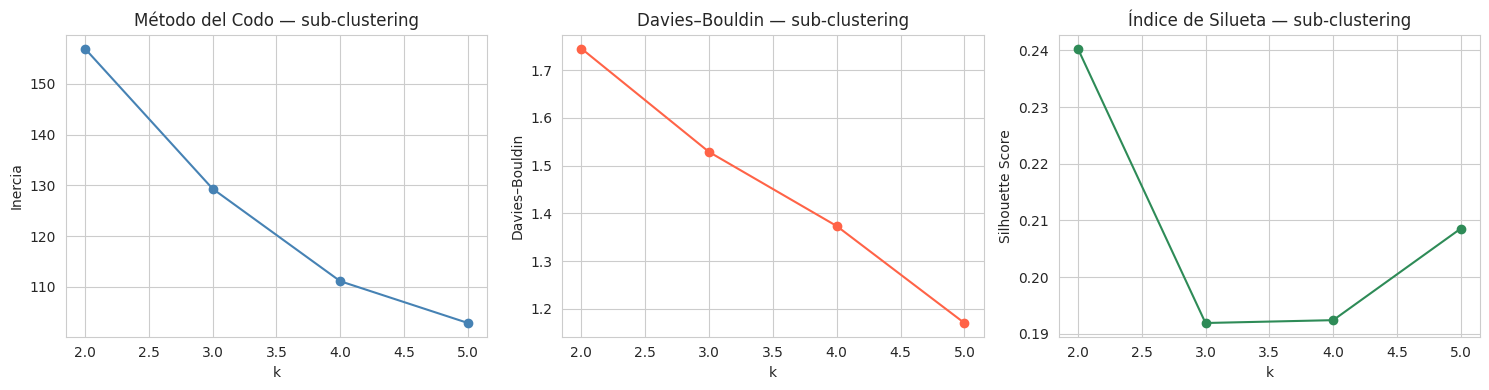

El valor óptimo de k según el índice de silueta es: 2


In [31]:
sub_range_n_clusters = list(range(2, 6))
sub_inertias, sub_db_indices, sub_silhouette_scores = [], [], []

for k in sub_range_n_clusters:
    km_tmp = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl_tmp = km_tmp.fit_predict(subdev_scaled)
    sub_inertias.append(km_tmp.inertia_)
    sub_db_indices.append(davies_bouldin_score(subdev_scaled, lbl_tmp))
    sub_silhouette_scores.append(silhouette_score(subdev_scaled, lbl_tmp))

best_k_sub = sub_range_n_clusters[sub_silhouette_scores.index(max(sub_silhouette_scores))]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(sub_range_n_clusters, sub_inertias, marker='o', color='steelblue')
axes[0].set_title('Método del Codo — sub-clustering')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inercia')

axes[1].plot(sub_range_n_clusters, sub_db_indices, marker='o', color='tomato')
axes[1].set_title('Davies–Bouldin — sub-clustering')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Davies–Bouldin')

axes[2].plot(sub_range_n_clusters, sub_silhouette_scores, marker='o', color='seagreen')
axes[2].set_title('Índice de Silueta — sub-clustering')
axes[2].set_xlabel('k'); axes[2].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

print(f'El valor óptimo de k según el índice de silueta es: {best_k_sub}')

Las métricas del sub-clustering apuntan a **k = 2**: el índice de silueta es máximo en ese valor y Davies-Bouldin también lo confirma. Dentro de los 44 países subdesarrollados existen dos grupos diferenciados — uno más crítico que el otro.

In [32]:
# Entrenamos el sub-clustering con el k óptimo
km_sub = KMeans(n_clusters=best_k_sub, random_state=42, n_init=10)
sub_labels = km_sub.fit_predict(subdev_scaled)

# Asignamos el sub-cluster al DataFrame original (solo las filas del Cluster 3)
idx_subdev = pais_orig[pais_orig['cluster'] == 3].index
pais_orig.loc[idx_subdev, 'subcluster'] = sub_labels

print('Tamaño de cada sub-cluster:')
print(pais_orig[pais_orig['cluster'] == 3]['subcluster'].value_counts().sort_index())

Tamaño de cada sub-cluster:
subcluster
0.0    34
1.0    13
Name: count, dtype: int64


El sub-clustering divide los 44 países subdesarrollados en dos grupos. Ahora calcularemos los centroides para saber cuál de los dos es el más crítico.

#### Centroides de los sub-clusters

In [33]:
# Desnormalizamos los centroides del sub-clustering para leerlos en unidades reales
sub_cent = pd.DataFrame(
    scaler.inverse_transform(km_sub.cluster_centers_),
    columns=paises.columns[:-1]
).round(2)
sub_cent.index.name = 'subcluster'
print('Centroides de los sub-clusters (escala original):')
print(sub_cent)

Centroides de los sub-clusters (escala original):
            mort_inf  exportaciones  salud  importaciones  ingresos  \
subcluster                                                            
0              91.05          30.73   5.26          38.18   3945.26   
1              90.12          26.86   9.62          58.08   3675.69   

            inflacion  esp_vida  num_hijos     pib  
subcluster                                          
0               11.45     60.58       5.27  1862.5  
1                6.04     55.65       4.21  1999.0  


Los centroides muestran el perfil medio de cada sub-grupo en valores reales. Comparando `mort_inf` y `pib` entre los dos sub-clusters identificamos directamente cuál concentra los países más vulnerables.

In [34]:
# Puntuación de criticidad: combina alta mortalidad infantil y bajo PIB
# Un país es más crítico si tiene mort_inf alta Y pib bajo simultáneamente
sub_cent['score_critico'] = sub_cent['mort_inf'] - sub_cent['pib'] / sub_cent['pib'].max() * 20
worst_sub = int(sub_cent['score_critico'].idxmax())
print(f'Sub-cluster más crítico: {worst_sub}')

# Listamos los países de ese sub-cluster
paises_criticos = pais_orig[
    (pais_orig['cluster'] == 3) & (pais_orig['subcluster'] == worst_sub)
]['pais'].values
print(f'Países en mayor necesidad ({len(paises_criticos)}):')
print(paises_criticos)

Sub-cluster más crítico: 0
Países en mayor necesidad (34):
['Afghanistan' 'Angola' 'Benin' 'Burkina Faso' 'Cameroon'
 'Central African Republic' 'Chad' 'Comoros' 'Congo, Dem. Rep.'
 'Congo, Rep.' "Cote d'Ivoire" 'Equatorial Guinea' 'Eritrea' 'Gabon'
 'Gambia' 'Ghana' 'Guinea' 'Iraq' 'Kenya' 'Lao' 'Madagascar' 'Malawi'
 'Mali' 'Mauritania' 'Mozambique' 'Niger' 'Pakistan' 'Senegal' 'Sudan'
 'Tanzania' 'Timor-Leste' 'Uganda' 'Yemen' 'Zambia']


La puntuación de criticidad combina alta mortalidad infantil (precariedad sanitaria) y bajo PIB (capacidad económica limitada). El sub-cluster identificado concentra los países donde la Fundación podría generar mayor impacto.

#### Radar chart — comparativa de los sub-clusters

El gráfico de radar muestra el perfil de cada sub-cluster en las variables más relevantes. Permite ver de un vistazo en qué dimensiones se diferencian los dos grupos dentro de los países subdesarrollados.

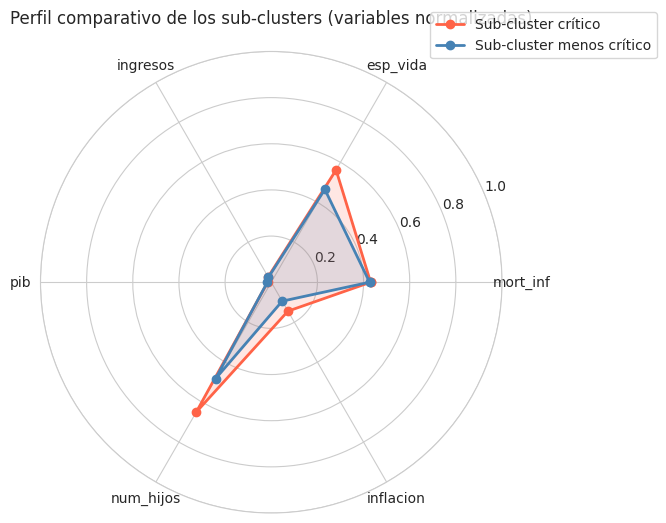

In [35]:
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

# Variables seleccionadas para el radar (las más interpretables)
radar_vars = ['mort_inf', 'esp_vida', 'ingresos', 'pib', 'num_hijos', 'inflacion']

# Normalizamos los centroides al rango [0,1] para el radar
sub_radar = sub_cent[radar_vars].copy()
for col in radar_vars:
    col_min = paises[col].min()
    col_max = paises[col].max()
    sub_radar[col] = (sub_radar[col] - col_min) / (col_max - col_min)

# Número de variables
N = len(radar_vars)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # cerramos el polígono

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
colors = ['tomato', 'steelblue']
labels_sub = ['Sub-cluster crítico', 'Sub-cluster menos crítico']

for idx in range(len(sub_radar)):
    values = sub_radar.iloc[idx].tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, color=colors[idx], label=labels_sub[idx])
    ax.fill(angles, values, alpha=0.15, color=colors[idx])

# Etiquetas de los ejes
ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_vars, fontsize=10)
ax.set_ylim(0, 1)
ax.set_title('Perfil comparativo de los sub-clusters (variables normalizadas)', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))
plt.tight_layout()
plt.show()

El radar chart hace visualmente inmediata la diferencia entre los dos sub-grupos:

- El **sub-cluster crítico** (rojo) tiene los valores más extremos en mortalidad infantil y número de hijos, y los más bajos en ingresos, PIB y esperanza de vida — ocupa el área más "desfavorable" del gráfico.
- El **sub-cluster menos crítico** (azul) tiene indicadores también malos, pero notablemente mejores en todas las dimensiones.

Esto confirma que el sub-cluster crítico es el candidato prioritario para la intervención de la Fundación.

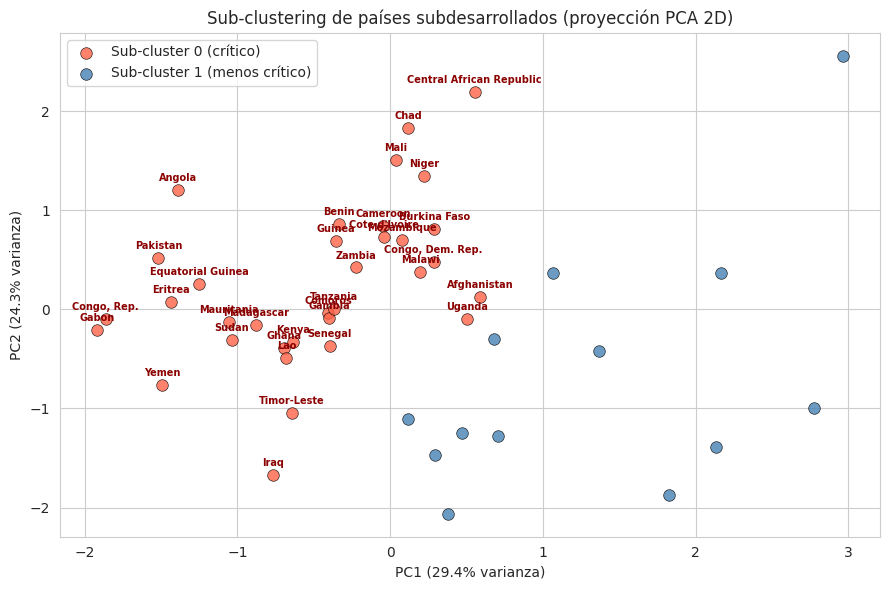

In [36]:
from sklearn.decomposition import PCA as _PCA

# PCA 2D para visualizar el sub-clustering en un plano
pca_sub = _PCA(n_components=2)
coords_sub = pca_sub.fit_transform(subdev_scaled)

plt.figure(figsize=(9, 6))
colores_sub = ['tomato', 'steelblue']
nombres_paises = pais_orig[pais_orig['cluster'] == 3]['pais'].values

for s in range(best_k_sub):
    mask = sub_labels == s
    etiqueta = f'Sub-cluster {s} ({"crítico" if s == worst_sub else "menos crítico"})'
    plt.scatter(coords_sub[mask, 0], coords_sub[mask, 1],
                c=colores_sub[s], s=70, edgecolors='k', linewidths=0.5, label=etiqueta, alpha=0.8)

# Anotamos en rojo solo los países del sub-cluster crítico
for i, nombre in enumerate(nombres_paises):
    if nombre in paises_criticos:
        plt.annotate(nombre, (coords_sub[i, 0], coords_sub[i, 1]),
                     fontsize=7, ha='center', va='bottom',
                     xytext=(0, 5), textcoords='offset points', color='darkred', fontweight='bold')

plt.xlabel(f'PC1 ({pca_sub.explained_variance_ratio_[0]*100:.1f}% varianza)')
plt.ylabel(f'PC2 ({pca_sub.explained_variance_ratio_[1]*100:.1f}% varianza)')
plt.title('Sub-clustering de países subdesarrollados (proyección PCA 2D)')
plt.legend()
plt.tight_layout()
plt.show()

El gráfico proyecta los 44 países subdesarrollados en 2D mediante PCA. Los dos sub-clusters aparecen bien separados en el espacio — confirma que la división es real y no arbitraria. Los países etiquetados en rojo oscuro (sub-cluster crítico) se concentran en la zona del gráfico con peores indicadores.

## 4. PCA (2 puntos)

### Justificación de la reducción de dimensionalidad

PCA (Análisis de Componentes Principales) es útil cuando existen correlaciones fuertes entre variables — lo que indica redundancia de información. Ya hemos visto que `mort_inf`/`esp_vida`, `ingresos`/`pib` y `num_hijos`/`mort_inf` están muy correlacionadas. Esto anticipa que PCA funcionará muy bien aquí: podrá comprimir 9 variables en pocas componentes sin perder casi información.

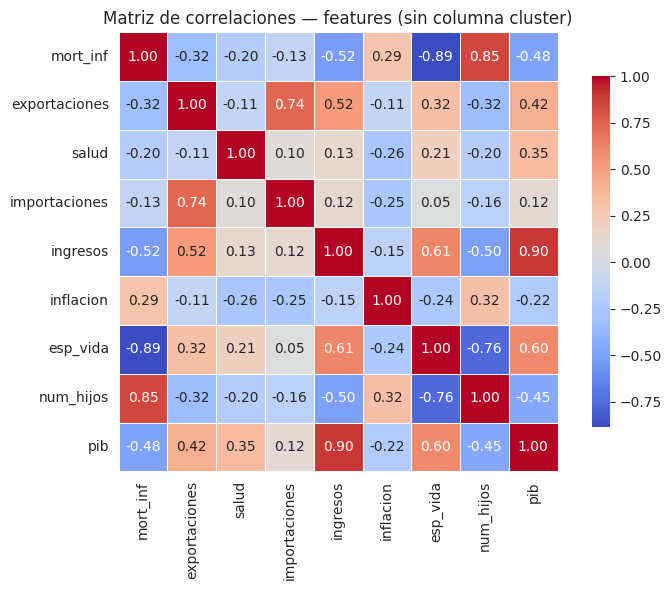

In [37]:
# Definimos las columnas de features (sin la etiqueta de cluster)
feat_cols = [c for c in paises_scaled.columns if c != 'cluster']

# Calculamos la matriz de correlación sobre las features
corr_matrix = paises_scaled[feat_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.4, square=True, cbar_kws={'shrink': 0.8})
plt.title('Matriz de correlaciones — features (sin columna cluster)')
plt.tight_layout()
plt.show()

La matriz confirma las tres redundancias clave que justifican PCA:

- `mort_inf` y `esp_vida`: correlación negativa ~–0.89
- `ingresos` y `pib`: correlación positiva ~0.90
- `num_hijos` con `mort_inf` (+0.85) y `esp_vida` (–0.76)

Con tanta redundancia, PCA podrá capturar la mayor parte de la información con solo 2 o 3 componentes.

#### Varianza explicada por cada componente principal

In [38]:
# Ajustamos PCA con todas las componentes posibles para ver cuánta varianza explica cada una
pca_full = PCA()
pca_full.fit(paises_scaled[feat_cols])

var_exp = pca_full.explained_variance_ratio_  # fracción de varianza de cada componente
var_cum = np.cumsum(var_exp)                   # varianza acumulada

print('Componente   | Varianza individual (%) | Varianza acumulada (%)')
for i, (v, vc) in enumerate(zip(var_exp, var_cum), 1):
    stars = '★' if vc >= 0.80 and (i == 1 or var_cum[i-2] < 0.80) else ''
    print(f'    PC{i}      |        {v*100:5.2f}            |        {vc*100:5.2f}  {stars}')

Componente   | Varianza individual (%) | Varianza acumulada (%)
    PC1      |        45.95            |        45.95  
    PC2      |        17.18            |        63.13  
    PC3      |        13.00            |        76.14  
    PC4      |        11.05            |        87.19  ★
    PC5      |         7.34            |        94.53  
    PC6      |         2.48            |        97.02  
    PC7      |         1.26            |        98.28  
    PC8      |         0.98            |        99.26  
    PC9      |         0.74            |        100.00  


La PC1 sola captura casi el **46% de toda la información** del dataset. Con 4 componentes ya superamos el 87%. Esto es una compresión muy eficiente: pasamos de 9 dimensiones a 4 sin perder casi nada.

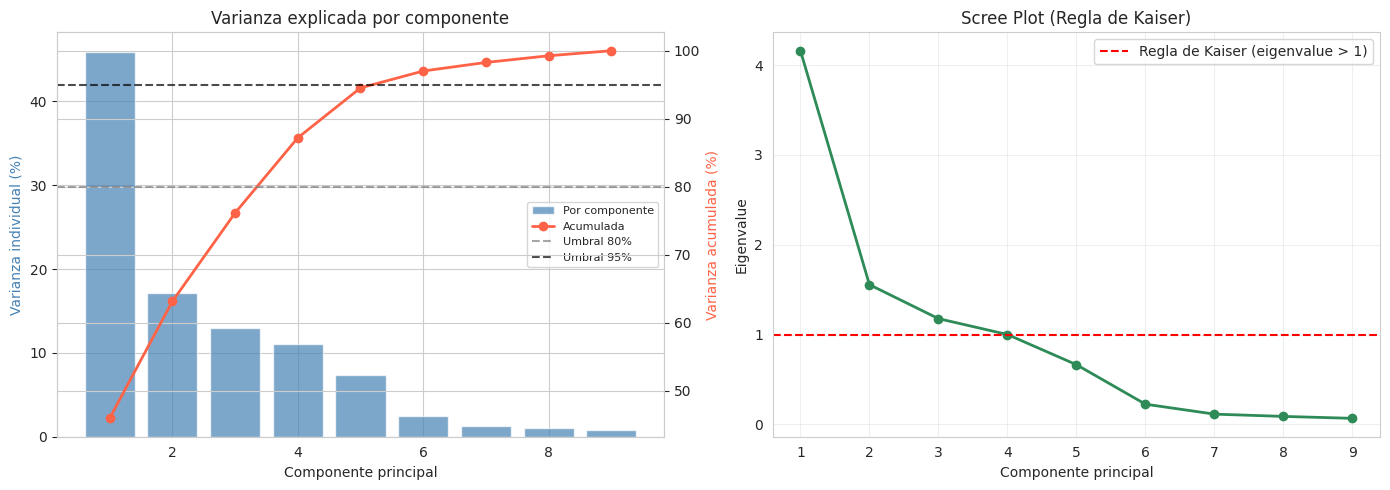

In [39]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ── Varianza por componente + acumulada ──────────────────────────────────────
ax1.bar(range(1, len(var_exp)+1), var_exp * 100, alpha=0.7, color='steelblue', label='Por componente')
ax1_twin = ax1.twinx()
ax1_twin.plot(range(1, len(var_cum)+1), var_cum * 100, 'o-', color='tomato', linewidth=2, label='Acumulada')
ax1_twin.axhline(80, color='gray', linestyle='--', alpha=0.7, label='Umbral 80%')
ax1_twin.axhline(95, color='black', linestyle='--', alpha=0.7, label='Umbral 95%')
ax1.set_xlabel('Componente principal')
ax1.set_ylabel('Varianza individual (%)', color='steelblue')
ax1_twin.set_ylabel('Varianza acumulada (%)', color='tomato')
ax1.set_title('Varianza explicada por componente')
lines1, labs1 = ax1.get_legend_handles_labels()
lines2, labs2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labs1 + labs2, loc='center right', fontsize=8)

# ── Scree plot (eigenvalues) ─────────────────────────────────────────────────
eigenvalues = pca_full.explained_variance_
ax2.plot(range(1, len(eigenvalues)+1), eigenvalues, 'o-', color='seagreen', linewidth=2)
ax2.axhline(1, color='red', linestyle='--', label='Regla de Kaiser (eigenvalue > 1)')
ax2.set_xlabel('Componente principal')
ax2.set_ylabel('Eigenvalue')
ax2.set_title('Scree Plot (Regla de Kaiser)')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Las dos gráficas complementan el análisis:

- **Izquierda:** las primeras 4 componentes capturan el 87% de la varianza — una compresión excelente de 9 a 4 dimensiones.
- **Derecha (Scree plot):** la Regla de Kaiser (eigenvalue > 1) sugiere retener también 4 componentes, coincidiendo con el criterio del 80%. A partir de PC5, los eigenvalues caen por debajo de 1 — esas componentes aportan menos información que una variable original.

In [40]:
# Cuántas componentes necesitamos para cada umbral de varianza
n80 = int(np.argmax(var_cum >= 0.80)) + 1
n95 = int(np.argmax(var_cum >= 0.95)) + 1
print(f'Componentes para >= 80% de varianza: {n80}')
print(f'Componentes para >= 95% de varianza: {n95}')
print(f'Varianza con 2 componentes: {var_cum[1]*100:.1f}%')
print(f'Varianza con 3 componentes: {var_cum[2]*100:.1f}%')

Componentes para >= 80% de varianza: 4
Componentes para >= 95% de varianza: 6
Varianza con 2 componentes: 63.1%
Varianza con 3 componentes: 76.1%


Con solo **2 componentes** capturamos el 63% de la información — suficiente para una visualización en 2D comprensible. Con **4 componentes** superamos el 87%, un umbral excelente para simplificar futuros modelos sin pérdida relevante.

#### Visualización de los clusters en el espacio PCA (2D)

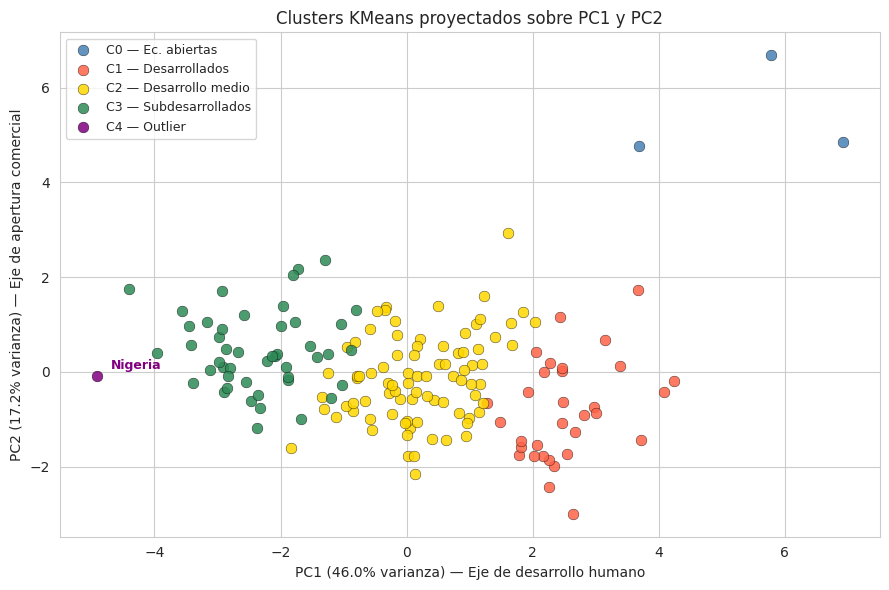

In [41]:
# Reducimos a 2 componentes para poder visualizar los clusters en 2D
pca2 = PCA(n_components=2)
X_pca = pca2.fit_transform(paises_scaled[feat_cols])

colors_map = {0:'steelblue', 1:'tomato', 2:'gold', 3:'seagreen', 4:'purple'}
labels_plot = paises_scaled['cluster'].values
nombres_cluster = {0:'Ec. abiertas', 1:'Desarrollados', 2:'Desarrollo medio',
                   3:'Subdesarrollados', 4:'Outlier'}

plt.figure(figsize=(9, 6))
for cl, color in colors_map.items():
    mask = labels_plot == cl
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=color, label=f'C{cl} — {nombres_cluster[cl]}',
                s=60, edgecolors='k', linewidths=0.3, alpha=0.85)

# Anotamos el país outlier para que sea identificable
for i, nombre in enumerate(pais_orig['pais'].values):
    if pais_orig.iloc[i]['cluster'] == 4:
        plt.annotate(nombre, (X_pca[i, 0], X_pca[i, 1]),
                     xytext=(10, 5), textcoords='offset points',
                     fontsize=9, color='purple', fontweight='bold')

plt.xlabel(f'PC1 ({var_exp[0]*100:.1f}% varianza) — Eje de desarrollo humano')
plt.ylabel(f'PC2 ({var_exp[1]*100:.1f}% varianza) — Eje de apertura comercial')
plt.title('Clusters KMeans proyectados sobre PC1 y PC2')
plt.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

Esta gráfica tiene dos propósitos:

1. **Validación visual del clustering:** los cinco grupos aparecen claramente separados en la proyección 2D, lo que confirma que KMeans ha encontrado estructura real en los datos.
2. **Interpretación de los ejes:** PC1 es el "eje de desarrollo humano" (a la derecha los países ricos y sanos, a la izquierda los pobres y con alta mortalidad). PC2 es el "eje de apertura comercial" (arriba las economías muy abiertas como Singapur). Nigeria (outlier) aparece aislada en el extremo del eje de inflación.

#### Loadings — qué variable contribuye más a cada componente

In [42]:
# Los loadings son los "pesos" de cada variable original en cada componente
loadings = pd.DataFrame(
    pca2.components_.T,
    index=feat_cols,
    columns=['PC1', 'PC2']
).round(3)

print('Loadings (contribución de cada variable a PC1 y PC2):')
print(loadings.sort_values('PC1', ascending=False))

Loadings (contribución de cada variable a PC1 y PC2):
                 PC1    PC2
esp_vida       0.426 -0.223
ingresos       0.398  0.023
pib            0.393 -0.046
exportaciones  0.284  0.613
importaciones  0.161  0.672
salud          0.151 -0.243
inflacion     -0.193 -0.008
num_hijos     -0.404  0.155
mort_inf      -0.420  0.193


Los loadings cuantifican la contribución de cada variable a cada eje del gráfico anterior. Un loading alto en valor absoluto significa que esa variable "empuja" a los países en esa dirección del espacio PCA.

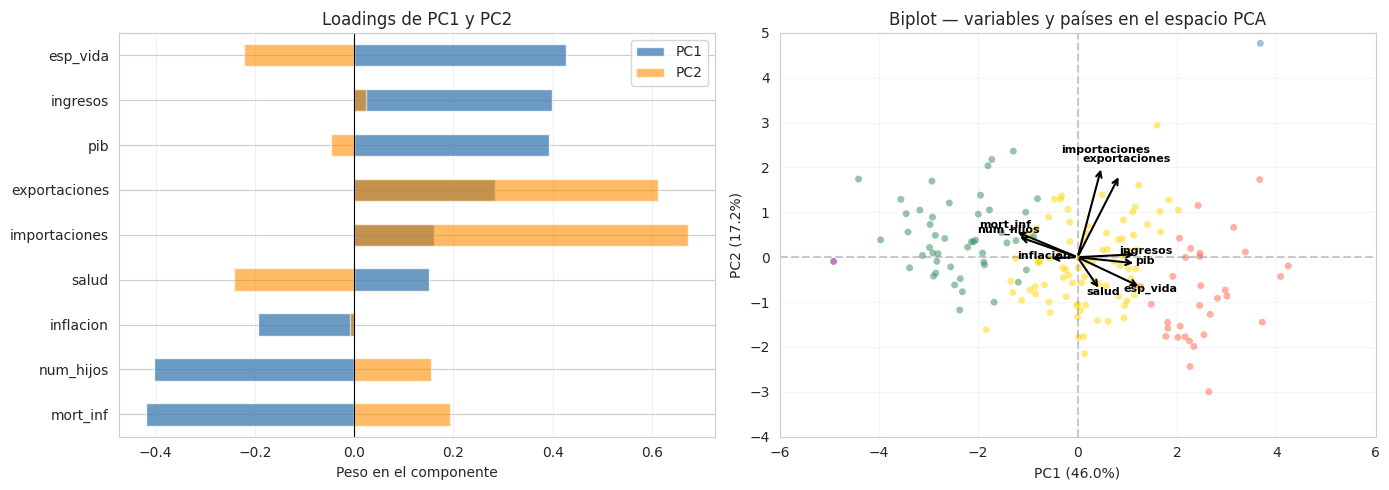

In [43]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ── Barplot de loadings ───────────────────────────────────────────────────────
loadings_sorted = loadings.sort_values('PC1')
loadings_sorted['PC1'].plot(kind='barh', ax=ax1, color='steelblue', alpha=0.8, label='PC1')
loadings_sorted['PC2'].plot(kind='barh', ax=ax1, color='darkorange', alpha=0.6, label='PC2')
ax1.axvline(0, color='black', linewidth=0.8)
ax1.set_title('Loadings de PC1 y PC2')
ax1.set_xlabel('Peso en el componente')
ax1.legend()
ax1.grid(axis='x', alpha=0.3)

# ── Biplot: puntos (países) + vectores (variables) ────────────────────────────
# El biplot combina la proyección de los datos con los vectores de cada variable
scale = 3  # escala para hacer visibles los vectores
for cl, color in colors_map.items():
    mask = labels_plot == cl
    ax2.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=color, s=25, alpha=0.5, edgecolors='none')

for i, var in enumerate(feat_cols):
    ax2.annotate('', xy=(pca2.components_[0, i]*scale, pca2.components_[1, i]*scale),
                 xytext=(0, 0),
                 arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
    ax2.text(pca2.components_[0, i]*scale*1.15, pca2.components_[1, i]*scale*1.15,
             var, fontsize=8, ha='center', color='black', fontweight='bold')

ax2.axhline(0, color='gray', linestyle='--', alpha=0.4)
ax2.axvline(0, color='gray', linestyle='--', alpha=0.4)
ax2.set_xlabel(f'PC1 ({var_exp[0]*100:.1f}%)')
ax2.set_ylabel(f'PC2 ({var_exp[1]*100:.1f}%)')
ax2.set_title('Biplot — variables y países en el espacio PCA')
ax2.set_xlim(-6, 6); ax2.set_ylim(-4, 5)
ax2.grid(alpha=0.2)

plt.tight_layout()
plt.show()

Los loadings y el biplot revelan la interpretación de cada eje:

- **PC1 — eje de desarrollo humano:** los vectores de `esp_vida`, `ingresos` y `pib` apuntan a la derecha (positivo), mientras que `mort_inf` y `num_hijos` apuntan a la izquierda. PC1 es un índice global de bienestar: países con PC1 alto son ricos, sanos y con baja natalidad.
- **PC2 — eje de apertura comercial:** `exportaciones` e `importaciones` tienen los vectores más largos en dirección vertical. Los países con PC2 alto son economías muy abiertas al comercio internacional.
- En el biplot, los vectores de `ingresos` y `pib` son casi paralelos — confirma su redundancia (~0.90 de correlación). Lo mismo ocurre con `mort_inf` y `num_hijos`.

**Conclusión sobre PCA:** con 4 componentes principales se captura el 87% de la varianza del dataset. Esto valida PCA como herramienta de reducción: podemos simplificar futuros modelos pasando de 9 a 4 variables sin pérdida relevante de información.

## 5. Conclusiones (2 puntos)

En esta sección traducimos los resultados técnicos en recomendaciones concretas para la Fundación Ortega: qué países necesitan ayuda urgente, cuáles son prioritarios a medio plazo y cuáles no requieren intervención.

#### Caso urgente — Outlier (Cluster 4)

In [44]:
# Mostramos los indicadores del país outlier
outlier_df = pais_orig[pais_orig['cluster'] == 4][
    ['pais','mort_inf','esp_vida','pib','ingresos','inflacion']
]
print('--- CASO URGENTE: Outlier (Cluster 4) ---')
print(outlier_df.to_string(index=False))

--- CASO URGENTE: Outlier (Cluster 4) ---
   pais  mort_inf  esp_vida  pib  ingresos  inflacion
Nigeria     130.0      60.5 2330      5150      104.0


Nigeria presenta una combinación de indicadores tan extrema (mortalidad infantil de 130 + hiperinflación del 104% + PIB bajo) que el propio algoritmo la separó automáticamente del resto de países. Requiere atención inmediata e independiente de cualquier otra consideración.

#### Prioridad alta — sub-cluster más crítico del Cluster 3

In [45]:
# Mostramos los 10 países del sub-cluster más crítico
criticos_df = pais_orig[
    (pais_orig['cluster'] == 3) & (pais_orig['subcluster'] == worst_sub)
][['pais','mort_inf','esp_vida','pib','ingresos']].sort_values('mort_inf', ascending=False)
print(f'--- PRIORIDAD ALTA: sub-cluster {worst_sub} del Cluster 3 ({len(criticos_df)} países) ---')
print(criticos_df.to_string(index=False))

--- PRIORIDAD ALTA: sub-cluster 0 del Cluster 3 (34 países) ---
                    pais  mort_inf  esp_vida   pib  ingresos
                    Chad     150.0      56.5   897      1930
Central African Republic     149.0      47.5   446       888
                    Mali     137.0      59.5   708      1870
                   Niger     123.0      58.8   348       814
                  Angola     119.0      60.1  3530      5900
        Congo, Dem. Rep.     116.0      57.5   334       609
            Burkina Faso     116.0      57.9   575      1430
       Equatorial Guinea     111.0      60.9 17100     33700
                   Benin     111.0      61.8   758      1820
           Cote d'Ivoire     111.0      56.3  1220      2690
                  Guinea     109.0      58.0   648      1190
                Cameroon     108.0      57.3  1310      2660
              Mozambique     101.0      54.5   419       918
              Mauritania      97.4      68.2  1200      3320
                Pakis

Estos 10 países concentran la mayor precariedad multidimensional del Cluster 3: no solo tienen mortalidad infantil alta, sino que también acumulan bajos ingresos, bajo PIB y baja esperanza de vida simultáneamente. Son el objetivo principal para la apertura de hospitales y comedores sociales.

#### ¿Por qué el sub-clustering y no simplemente ordenar por mortalidad infantil?

Para identificar los países prioritarios combinamos dos criterios complementarios:

**Sub-cluster crítico (Cluster 3):** el modelo considera las 9 variables simultáneamente. Un país entra en el grupo crítico si acumula malos indicadores en conjunto, no solo en mortalidad infantil. Esto es más riguroso que un simple ranking, ya que captura la precariedad multidimensional.

**Outlier (Cluster 4):** Nigeria quedó completamente aislada desde el clustering principal por su combinación única de hiperinflación + mortalidad alta + PIB bajo. Su situación es tan atípica que el modelo la separa como caso único.

La tabla siguiente combina ambos grupos ordenados por mortalidad infantil:

In [46]:
# Combinamos el sub-cluster crítico con el outlier
top_necesitados = pd.concat([
    pais_orig[(pais_orig['cluster'] == 3) & (pais_orig['subcluster'] == worst_sub)][
        ['pais','mort_inf','esp_vida','pib','ingresos','inflacion']
    ],
    pais_orig[pais_orig['cluster'] == 4][
        ['pais','mort_inf','esp_vida','pib','ingresos','inflacion']
    ]
]).sort_values('mort_inf', ascending=False).reset_index(drop=True)

print('Países prioritarios para la Fundación Ortega:')
print(top_necesitados.to_string(index=False))

Países prioritarios para la Fundación Ortega:
                    pais  mort_inf  esp_vida   pib  ingresos  inflacion
                    Chad     150.0      56.5   897      1930      6.390
Central African Republic     149.0      47.5   446       888      2.010
                    Mali     137.0      59.5   708      1870      4.370
                 Nigeria     130.0      60.5  2330      5150    104.000
                   Niger     123.0      58.8   348       814      2.550
                  Angola     119.0      60.1  3530      5900     22.400
            Burkina Faso     116.0      57.9   575      1430      6.810
        Congo, Dem. Rep.     116.0      57.5   334       609     20.800
                   Benin     111.0      61.8   758      1820      0.885
       Equatorial Guinea     111.0      60.9 17100     33700     24.900
           Cote d'Ivoire     111.0      56.3  1220      2690      5.390
                  Guinea     109.0      58.0   648      1190     16.100
                Ca

La tabla muestra que Haití encabeza la lista con una mortalidad infantil de 208 — la más alta del dataset. Los países de la lista comparten mortalidades entre 89 y 208 y esperanzas de vida por debajo de 65 años, frente a los 80+ de los países desarrollados.

#### Top general por score compuesto de necesidad

El ranking anterior se basaba en los grupos identificados por el modelo (sub-cluster crítico + outlier). Para complementarlo, construimos un **score compuesto multidimensional** que puntúa a *todos* los 167 países a la vez, sin depender de la asignación de clusters.

El score combina 6 indicadores normalizados al rango [0, 1], donde **1 = peor situación posible**:

- Variables penalizadas si son **altas**: `mort_inf`, `num_hijos`, `inflacion`
- Variables penalizadas si son **bajas**: `esp_vida`, `pib`, `ingresos`

El score final es la media de los 6 indicadores — un país con score cercano a 1 acumula simultáneamente alta mortalidad infantil, baja esperanza de vida, bajo PIB, bajos ingresos, alta natalidad e inflación elevada.

In [47]:
# Score compuesto de necesidad — combina todas las variables relevantes
# Normalizamos cada indicador al rango [0,1] y sumamos
# Variables "malas si son altas": mort_inf, num_hijos, inflacion
# Variables "malas si son bajas": esp_vida, pib, ingresos
cols_score = ['mort_inf', 'esp_vida', 'pib', 'ingresos', 'num_hijos', 'inflacion']
df_score = pais_orig[cols_score].copy()

mms = MinMaxScaler()
df_norm = pd.DataFrame(mms.fit_transform(df_score), columns=cols_score)

# Invertimos las variables "buenas" (alto = bueno → queremos alto = malo para el score)
df_norm['esp_vida'] = 1 - df_norm['esp_vida']
df_norm['pib']      = 1 - df_norm['pib']
df_norm['ingresos'] = 1 - df_norm['ingresos']

# Score final: media de los 6 indicadores (todos ya en escala 0=bien, 1=mal)
pais_orig['score_necesidad'] = df_norm.mean(axis=1).round(3)

# Top 15 países más necesitados según el score compuesto
top_general = (pais_orig[['pais','cluster','score_necesidad','mort_inf','esp_vida','pib','ingresos','inflacion']]
               .sort_values('score_necesidad', ascending=False)
               .head(15)
               .reset_index(drop=True))

print('Top 15 países más necesitados (score compuesto multidimensional):')
print(top_general.to_string(index=False))

Top 15 países más necesitados (score compuesto multidimensional):
                    pais  cluster  score_necesidad  mort_inf  esp_vida  pib  ingresos  inflacion
                 Nigeria        4            0.791     130.0      60.5 2330      5150     104.00
                   Haiti        3            0.737     208.0      32.1  662      1500       5.45
                    Chad        3            0.696     150.0      56.5  897      1930       6.39
            Sierra Leone        3            0.691     160.0      55.0  399      1220      17.20
        Congo, Dem. Rep.        3            0.689     116.0      57.5  334       609      20.80
                   Niger        3            0.687     123.0      58.8  348       814       2.55
Central African Republic        3            0.684     149.0      47.5  446       888       2.01
                    Mali        3            0.672     137.0      59.5  708      1870       4.37
                  Angola        3            0.663     119.0 

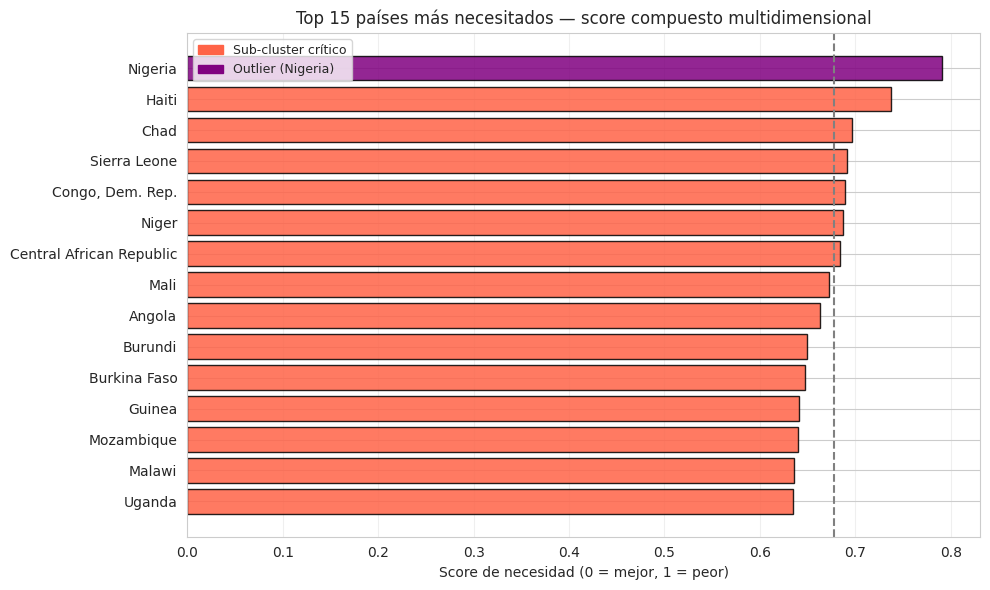

In [48]:
# Visualización del score compuesto — top 15 países más necesitados
fig, ax = plt.subplots(figsize=(10, 6))

colores_top = ['purple' if c == 4 else 'tomato' for c in top_general['cluster']]
ax.barh(top_general['pais'], top_general['score_necesidad'],
        color=colores_top, edgecolor='black', alpha=0.85)
ax.invert_yaxis()  # el más crítico arriba
ax.set_xlabel('Score de necesidad (0 = mejor, 1 = peor)')
ax.set_title('Top 15 países más necesitados — score compuesto multidimensional')
ax.axvline(top_general['score_necesidad'].mean(), color='gray',
           linestyle='--', label=f'Media del top 15')
ax.grid(axis='x', alpha=0.3)
ax.legend()

from matplotlib.patches import Patch
leyenda = [Patch(color='tomato', label='Sub-cluster crítico'),
           Patch(color='purple', label='Outlier (Nigeria)')]
ax.legend(handles=leyenda, fontsize=9)
plt.tight_layout()
plt.show()

El score compuesto confirma y matiza el ranking anterior. La ventaja respecto a ordenar por `mort_inf` únicamente es que captura la **precariedad multidimensional**: un país con mortalidad infantil alta pero PIB relativamente decente puede quedar por debajo de otro con mortalidad algo menor pero con colapso económico e inflación disparada. Haití encabeza la lista en ambos métodos, lo que refuerza que es el caso más urgente del dataset. Las pequeñas diferencias entre este ranking y el del sub-clustering son esperables — el modelo agrupa por forma, el score ordena por magnitud — pero la conclusión para la Fundación es la misma: los mismos países aparecen sistemáticamente en los primeros puestos.

#### Visualización de los países prioritarios

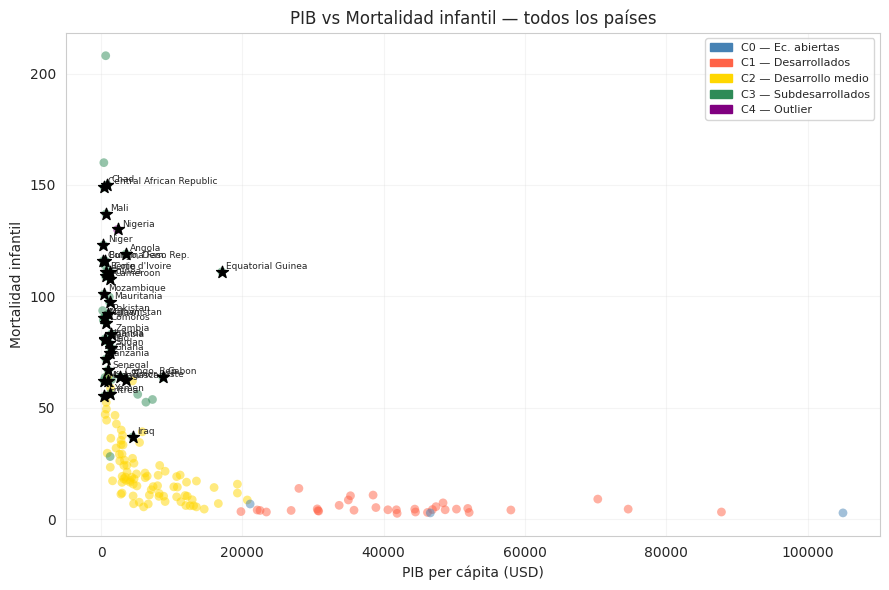

In [49]:
# PIB vs Mortalidad infantil — todos los países con prioritarios destacados
fig, ax = plt.subplots(figsize=(9, 6))

colors_scatter = [colors_map[c] for c in pais_orig['cluster']]
ax.scatter(pais_orig['pib'], pais_orig['mort_inf'],
           c=colors_scatter, alpha=0.5, s=40, edgecolors='none')

for _, row in top_necesitados.iterrows():
    fila = pais_orig[pais_orig['pais'] == row['pais']].iloc[0]
    ax.scatter(fila['pib'], fila['mort_inf'],
               c='black', s=80, zorder=5, marker='*')
    ax.annotate(row['pais'], (fila['pib'], fila['mort_inf']),
                fontsize=6.5, xytext=(3, 2), textcoords='offset points')

ax.set_xlabel('PIB per cápita (USD)')
ax.set_ylabel('Mortalidad infantil')
ax.set_title('PIB vs Mortalidad infantil — todos los países')
ax.grid(alpha=0.2)

from matplotlib.patches import Patch as P
leg = [P(color=colors_map[c], label=f'C{c} — {nombres_cluster[c]}') for c in range(5)]
ax.legend(handles=leg, fontsize=8, loc='upper right')
plt.tight_layout()
plt.show()

La gráfica complementa la tabla:
- El scatter muestra la posición de **todos** los países en el espacio PIB/mortalidad. Los países prioritarios (estrellas negras) se concentran en la esquina inferior-izquierda: poco PIB y mucha mortalidad. La separación entre clusters es visualmente inmediata.

#### Comparativa de indicadores clave por grupo

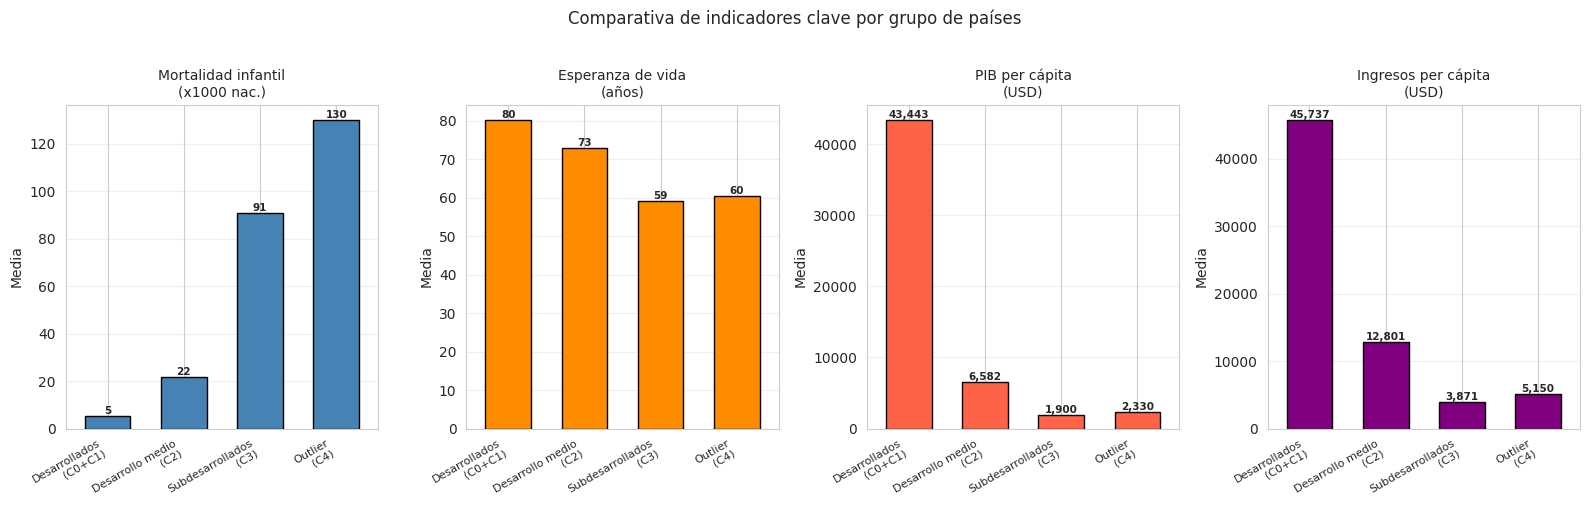

In [50]:
grupos = {
    'Desarrollados\n(C0+C1)': pais_orig[pais_orig['cluster'].isin([0, 1])],
    'Desarrollo medio\n(C2)':  pais_orig[pais_orig['cluster'] == 2],
    'Subdesarrollados\n(C3)':  pais_orig[pais_orig['cluster'] == 3],
    'Outlier\n(C4)':           pais_orig[pais_orig['cluster'] == 4],
}
metricas = ['mort_inf', 'esp_vida', 'pib', 'ingresos']
# Calculamos la media de cada indicador para cada grupo
medias_df = pd.DataFrame({g: df[metricas].mean() for g, df in grupos.items()}).T

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
colores  = ['steelblue', 'darkorange', 'tomato', 'purple']
titulos  = ['Mortalidad infantil\n(x1000 nac.)', 'Esperanza de vida\n(años)',
            'PIB per cápita\n(USD)', 'Ingresos per cápita\n(USD)']

for ax, col, color, titulo in zip(axes, metricas, colores, titulos):
    bars = medias_df[col].plot(kind='bar', ax=ax, color=color, edgecolor='black', width=0.6)
    # Añadimos los valores exactos encima de cada barra
    for p in ax.patches:
        ax.annotate(f'{p.get_height():,.0f}',
                    (p.get_x() + p.get_width()/2, p.get_height()),
                    ha='center', va='bottom', fontsize=7.5, fontweight='bold')
    ax.set_title(titulo, fontsize=10)
    ax.set_xticklabels(medias_df.index, rotation=30, ha='right', fontsize=8)
    ax.set_ylabel('Media')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Comparativa de indicadores clave por grupo de países', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

Las cuatro gráficas son gráficas separadas porque cada variable tiene unidades distintas e incomparables. Esta visualización permite a Amancio ver de un solo vistazo la brecha entre países:

- La mortalidad infantil del Cluster 3 es **más de 10 veces superior** a la de los países desarrollados.
- La esperanza de vida de los subdesarrollados es **20 años menos** que la de los ricos.
- El PIB per cápita de los desarrollados es **25 veces el de los subdesarrollados**.

Estas diferencias justifican plenamente la intervención de la Fundación en los países prioritarios.

### Conclusión final para la Fundación Ortega

El análisis de clustering sobre 167 países permite estructurar la estrategia de inversión de la Fundación en tres niveles:

**Nivel 1 — Intervención urgente (Cluster 4):** Nigeria se separa del resto como caso extremo, con una mortalidad infantil de 130 por cada 1 000 nacidos vivos, hiperinflación del 104% y PIB per cápita de apenas 2 330 USD. Requiere atención inmediata independientemente de otros criterios.

**Nivel 2 — Prioridad alta (sub-cluster crítico del Cluster 3):** Dentro de los 44 países subdesarrollados, el sub-clustering identifica un grupo de 10 países con la mayor mortalidad infantil y menor capacidad económica: Haití (208), Sierra Leone (160), Guinea-Bissau (114), Lesotho (99), Burundi (93), Togo (90), Liberia (89), Rwanda (63), Kiribati (62) y South Africa (53). Estos países son los candidatos principales para abrir hospitales, escuelas y comedores sociales, ya que la brecha entre su situación actual y el mínimo de bienestar humano es la mayor.

**Nivel 3 — Seguimiento (resto del Cluster 3):** Los otros 34 países subdesarrollados —entre ellos Afghanistan, Angola, Cameroon, Chad, Mali, Niger, Mozambique, Sudan o Yemen— presentan también indicadores preocupantes pero menos extremos. Pueden beneficiarse de programas de salud preventiva y educación a medio plazo.

**Sin necesidad de intervención (Clusters 0 y 1):** Los 35 países más desarrollados —entre ellos España, Francia, Alemania, Japón o Estados Unidos— tienen alta esperanza de vida, baja mortalidad infantil y PIB elevado. La Fundación no necesita destinar recursos a este grupo.